# Persian Poetry Semantic Similarity: Performance Analysis & Insights

This notebook provides comprehensive analysis of LLM performance on Persian poetry semantic outlier detection.

## 1. Setup and Data Loading

**Overview:** Imports required libraries and loads the experiment results, questions, and answer keys. Sets up the analysis environment and provides an initial overview of the dataset size.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import patheffects
import seaborn as sns
import json
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, pearsonr
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter, defaultdict
import warnings
import arabic_reshaper
from bidi.algorithm import get_display
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12  # Increased from 11 to 12
plt.rcParams['axes.labelsize'] = 13  # Increased
plt.rcParams['axes.titlesize'] = 15  # Increased
plt.rcParams['xtick.labelsize'] = 12  # Increased
plt.rcParams['ytick.labelsize'] = 12  # Increased
plt.rcParams['legend.fontsize'] = 12  # Increased
plt.rcParams['figure.titlesize'] = 17  # Increased

# Configure matplotlib to use Vazirmatn font for Persian text
plt.rcParams['font.family'] = 'Vazirmatn'
# Fallback fonts in case Vazirmatn is not available
plt.rcParams['font.sans-serif'] = ['Vazirmatn', 'Arial', 'DejaVu Sans']

# For non-Persian text (English), keep good defaults
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'

# Add more breathing room in plots
plt.rcParams['xtick.major.pad'] = 8  # Space between ticks and labels
plt.rcParams['ytick.major.pad'] = 8
plt.rcParams['axes.labelpad'] = 12  # Space between axis label and tick labels
plt.rcParams['axes.titlepad'] = 20  # Space between title and plot

# Verify font is available
available_fonts = [f.name for f in fm.fontManager.ttflist]
has_vazirmatn = any('Vazirmatn' in f for f in available_fonts)

print("✅ Libraries loaded successfully")
if has_vazirmatn:
    print("✅ Plot font set to: Vazirmatn (Persian text support enabled)")
else:
    print("⚠️  Vazirmatn not found, using fallback font")
    print("   To install Vazirmatn: Download from https://github.com/rastikerdar/vazirmatn")
    print(f"   Currently using: {plt.rcParams['font.family']}")

✅ Libraries loaded successfully
✅ Plot font set to: Vazirmatn (Persian text support enabled)


In [2]:
def format_persian_text(text):
    """Format Persian text for proper display in matplotlib"""
    if not isinstance(text, str):
        return text
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

In [ ]:
# Load experiment results
results_df = pd.read_csv('experiment-answers-few-shot-improved.csv')

# Exclude specific model from analysis
results_df = results_df[results_df['model_name'] != 'qwen/qwen3-235b-a22b']

# Load questions and answer keys
with open('../data/gherabat-book/questions-outliers.json', 'r', encoding='utf-8') as f:
    questions_data = json.load(f)

with open('../data/gherabat-book/answer_keys.json', 'r', encoding='utf-8') as f:
    answer_keys = json.load(f)

# Extract all questions from the nested structure
all_questions = []
for page in questions_data['pages']:
    if 'data' in page and 'questions' in page['data']:
        all_questions.extend(page['data']['questions'])

# Create question lookup dictionary
questions_dict = {q['id']: q for q in all_questions}

print(f"📊 Loaded {len(results_df)} model responses")
print(f"📚 {len(results_df['model_name'].unique())} unique models tested")
print(results_df.info())


📊 Loaded 5000 model responses
📚 29 unique models tested
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model_name         5000 non-null   object 
 1   question_id        5000 non-null   int64  
 2   model_answer       4947 non-null   float64
 3   correct_answer     5000 non-null   int64  
 4   is_correct         5000 non-null   bool   
 5   completion_tokens  4998 non-null   float64
dtypes: bool(1), float64(2), int64(2), object(1)
memory usage: 239.3+ KB
None


## 2. Model Performance Analysis

**Overview:** Comprehensive evaluation of how well each model performs on the Persian poetry semantic similarity task, including accuracy rankings, efficiency metrics, and family-level comparisons.

### 2.1 Overall Performance Metrics

Individual model accuracy scores, confidence intervals, and efficiency metrics. Identifies the best and worst performing models and shows how far above random chance (25%) each model performs.

In [4]:
# Calculate comprehensive performance metrics per model
def calculate_model_metrics(df):
    model_stats = df.groupby('model_name').agg({
        'is_correct': ['sum', 'count', 'mean', 'std'],
        'completion_tokens': ['sum', 'mean', 'median']
    }).round(4)

    model_stats.columns = ['_'.join(col).strip() for col in model_stats.columns.values]
    model_stats.columns = ['correct_count', 'total_questions', 'accuracy', 'accuracy_std',
                           'total_tokens', 'avg_tokens_per_question', 'median_tokens']

    # Calculate additional metrics
    model_stats['accuracy_pct'] = (model_stats['accuracy'] * 100).round(2)
    model_stats['error_rate'] = ((1 - model_stats['accuracy']) * 100).round(2)

    # Calculate 95% confidence interval for accuracy
    model_stats['ci_lower'] = model_stats.apply(
        lambda row: max(0, row['accuracy'] - 1.96 * row['accuracy_std'] / np.sqrt(row['total_questions'])),
        axis=1
    ) * 100
    model_stats['ci_upper'] = model_stats.apply(
        lambda row: min(1, row['accuracy'] + 1.96 * row['accuracy_std'] / np.sqrt(row['total_questions'])),
        axis=1
    ) * 100

    # Efficiency: accuracy per 1000 tokens
    model_stats['efficiency'] = (model_stats['correct_count'] / (model_stats['total_tokens'] / 1000)).round(2)

    # Extract model family
    model_stats['family'] = model_stats.index.str.split('/').str[0]

    return model_stats.sort_values('accuracy', ascending=False)

model_performance = calculate_model_metrics(results_df)

print("\n🏆 Top 10 Models by Accuracy:")
print(model_performance[['accuracy_pct', 'error_rate', 'total_questions', 'efficiency', 'ci_lower', 'ci_upper']].head(10))

print("\n📊 Performance Summary Statistics:")
print(f"Mean Accuracy: {model_performance['accuracy_pct'].mean():.2f}%")
print(f"Median Accuracy: {model_performance['accuracy_pct'].median():.2f}%")
print(f"Std Dev: {model_performance['accuracy_pct'].std():.2f}%")
print(f"Best Model: {model_performance.index[0]} ({model_performance['accuracy_pct'].iloc[0]:.2f}%)")
print(f"Worst Model: {model_performance.index[-1]} ({model_performance['accuracy_pct'].iloc[-1]:.2f}%)")
print(f"Performance Range: {model_performance['accuracy_pct'].max() - model_performance['accuracy_pct'].min():.2f}%")


🏆 Top 10 Models by Accuracy:
                             accuracy_pct  error_rate  total_questions  \
model_name                                                               
google/gemini-2.5-pro                70.0        30.0              100   
moonshotai/kimi-k2-thinking          62.0        38.0              100   
google/gemini-2.5-flash              61.0        39.0              200   
qwen/qwen3-max                       59.0        41.0              100   
openai/gpt-5-mini                    57.0        43.0              100   
deepseek/deepseek-r1-0528            56.0        44.0              100   
anthropic/claude-haiku-4.5           55.0        45.0              100   
x-ai/grok-4-fast                     53.0        47.0              200   
x-ai/grok-3-mini                     53.0        47.0              200   
openai/gpt-4.1-mini                  53.0        47.0              100   

                             efficiency   ci_lower   ci_upper  
model_name       

#### Top Models Accuracy Chart

Visual ranking of the best-performing models based on their accuracy in identifying semantic outliers in Persian poetry.

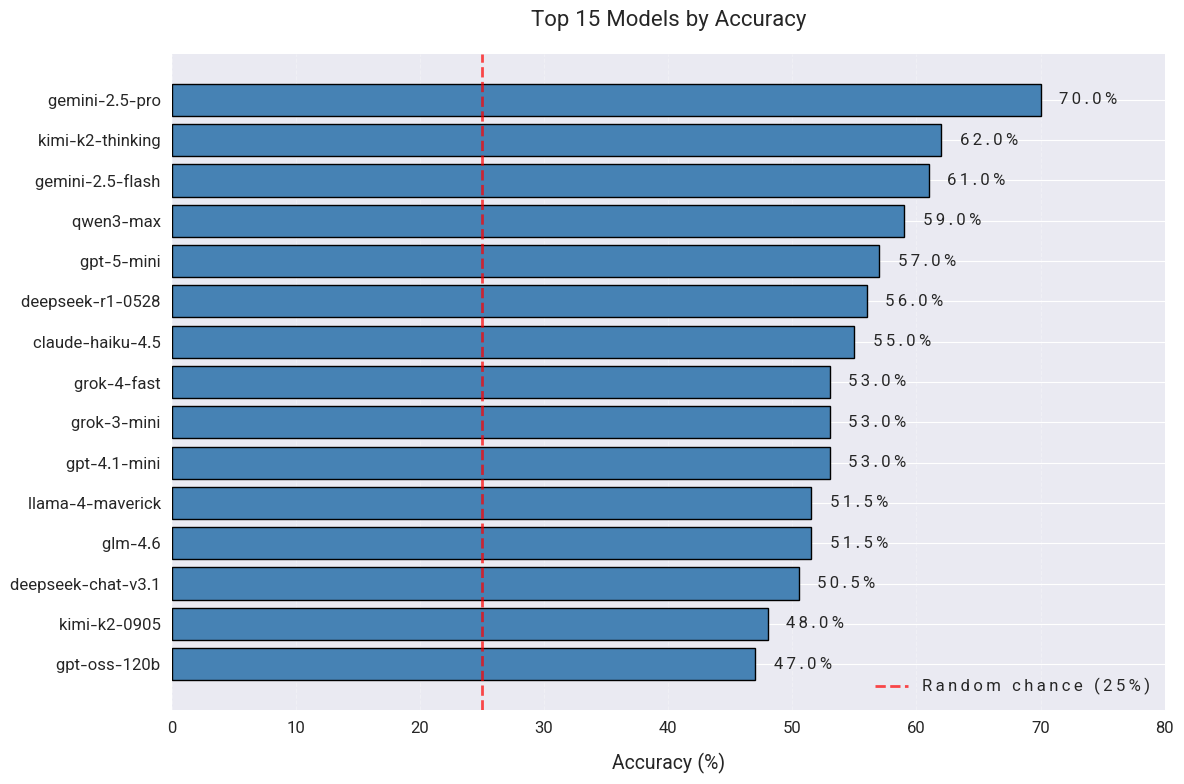


📊 Top 15 Models:
   1. google/gemini-2.5-pro                    70.0%
   2. moonshotai/kimi-k2-thinking              62.0%
   3. google/gemini-2.5-flash                  61.0%
   4. qwen/qwen3-max                           59.0%
   5. openai/gpt-5-mini                        57.0%
   6. deepseek/deepseek-r1-0528                56.0%
   7. anthropic/claude-haiku-4.5               55.0%
   8. x-ai/grok-4-fast                         53.0%
   9. x-ai/grok-3-mini                         53.0%
  10. openai/gpt-4.1-mini                      53.0%
  11. meta-llama/llama-4-maverick              51.5%
  12. z-ai/glm-4.6                             51.5%
  13. deepseek/deepseek-chat-v3.1              50.5%
  14. moonshotai/kimi-k2-0905                  48.0%
  15. openai/gpt-oss-120b                      47.0%


In [5]:
# Visualize top models by accuracy
# Get top 15 models
top_models = model_performance.nlargest(15, 'accuracy_pct')

# Helper function to add spacing to numbers
def add_letter_spacing(text, space='\u2009'):
    """Add thin space between characters for better readability"""
    return space.join(text)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart with uniform color
bars = ax.barh(range(len(top_models)), top_models['accuracy_pct'],
               color='steelblue', edgecolor='black', linewidth=1)

# Set labels with increased font size and spacing
ax.set_yticks(range(len(top_models)))
# Add thin spaces between characters in model names for better readability
model_labels = [add_letter_spacing(name.split('/')[-1], '‌') for name in top_models.index]
ax.set_yticklabels(model_labels, fontsize=12)
ax.set_xlabel(add_letter_spacing('Accuracy (%)', '‌'), fontsize=14, labelpad=12)
ax.set_title('Top 15 Models by Accuracy', fontsize=16, fontweight='bold', pad=20)

# Add random chance line
ax.axvline(x=25, color='red', linestyle='--', alpha=0.7, linewidth=2,
           label=add_letter_spacing('Random chance (25%)', '\u2009'))

# Add value labels on bars with larger font and spacing
for i, (idx, row) in enumerate(top_models.iterrows()):
    # Add thin spaces between digits for better readability
    percentage_text = add_letter_spacing(f"{row['accuracy_pct']:.1f}%", '\u2009')
    ax.text(row['accuracy_pct'] + 1.5, i, percentage_text,
            va='center', fontsize=12, fontweight='semibold')

# Add legend for random chance line
ax.legend(loc='lower right', fontsize=12)

# Invert y-axis so best model is on top
ax.invert_yaxis()

# Grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(0, max(top_models['accuracy_pct']) + 10)

# Adjust tick parameters for better spacing
ax.tick_params(axis='both', which='major', labelsize=12, pad=8)

# Add more spacing for tick labels
for label in ax.get_xticklabels():
    label.set_text(add_letter_spacing(label.get_text(), '\u2009'))
ax.set_xticklabels(ax.get_xticklabels())

plt.tight_layout()
plt.show()

print(f"\n📊 Top 15 Models:")
for i, (model, row) in enumerate(top_models.iterrows(), 1):
    print(f"  {i:2d}. {model:<40} {row['accuracy_pct']:.1f}%")

### 2.2 Model Family Comparison

Performance differences across model families (Google, OpenAI, Meta, etc.). Reveals which organizations' models are better at understanding Persian poetry semantics.


🏢 Performance by Model Family:
            accuracy_pct_mean  accuracy_pct_median  accuracy_pct_std  \
family                                                                 
anthropic               55.00                55.00               NaN   
moonshotai              55.00                55.00              9.90   
deepseek                53.25                53.25              3.89   
x-ai                    53.00                53.00              0.00   
z-ai                    51.50                51.50               NaN   
google                  48.08                43.25             14.49   
openai                  46.75                50.00             11.90   
meta-llama              44.00                42.50              6.87   
qwen                    40.30                37.50             10.88   
mistralai               38.50                38.50              9.19   
cohere                  32.50                32.50               NaN   

            accuracy_pct_min  a

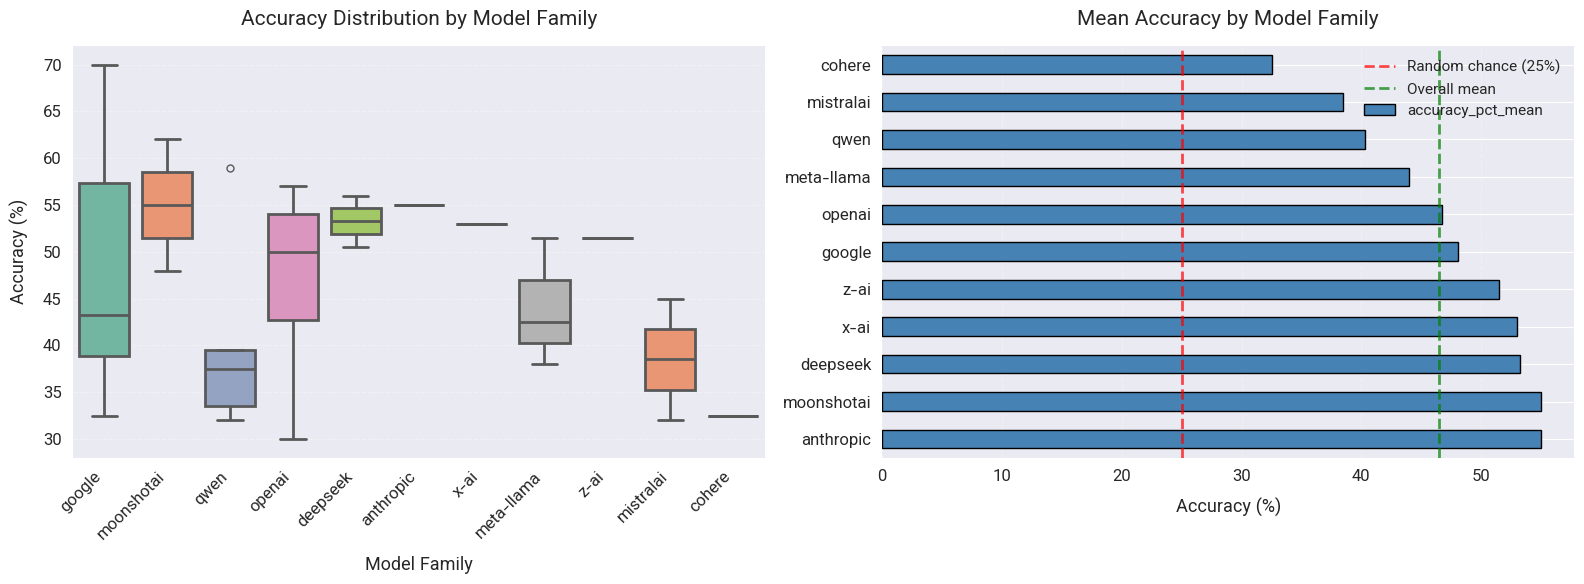

In [6]:
# Analyze performance by model family
family_performance = model_performance.groupby('family').agg({
    'accuracy_pct': ['mean', 'median', 'std', 'min', 'max'],
    'efficiency': ['mean', 'median'],
    'total_questions': 'sum'
}).round(2)

family_performance.columns = ['_'.join(col).strip() for col in family_performance.columns.values]
family_performance = family_performance.sort_values('accuracy_pct_mean', ascending=False)

print("\n🏢 Performance by Model Family:")
print(family_performance)

# Visualize family comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of accuracy by family - using seaborn for better visibility
import seaborn as sns
model_perf_reset = model_performance.reset_index()
sns.boxplot(data=model_perf_reset, x='family', y='accuracy_pct', ax=axes[0],
            palette='Set2', linewidth=2, fliersize=5)
axes[0].set_title('Accuracy Distribution by Model Family', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Model Family', fontsize=13, labelpad=10)
axes[0].set_ylabel('Accuracy (%)', fontsize=13, labelpad=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Bar plot of mean accuracy
family_performance['accuracy_pct_mean'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black', linewidth=1)
axes[1].set_title('Mean Accuracy by Model Family', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Accuracy (%)', fontsize=13, labelpad=10)
axes[1].set_ylabel('')
axes[1].axvline(x=25, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Random chance (25%)')
axes[1].axvline(x=model_performance['accuracy_pct'].mean(), color='green', linestyle='--', alpha=0.7, linewidth=2, label='Overall mean')
axes[1].legend(fontsize=11)
axes[1].tick_params(labelsize=12)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 2.3 Token Efficiency Analysis

The relationship between computational cost (tokens used) and accuracy. Identifies models that achieve good performance with fewer tokens, which is important for cost-effectiveness.

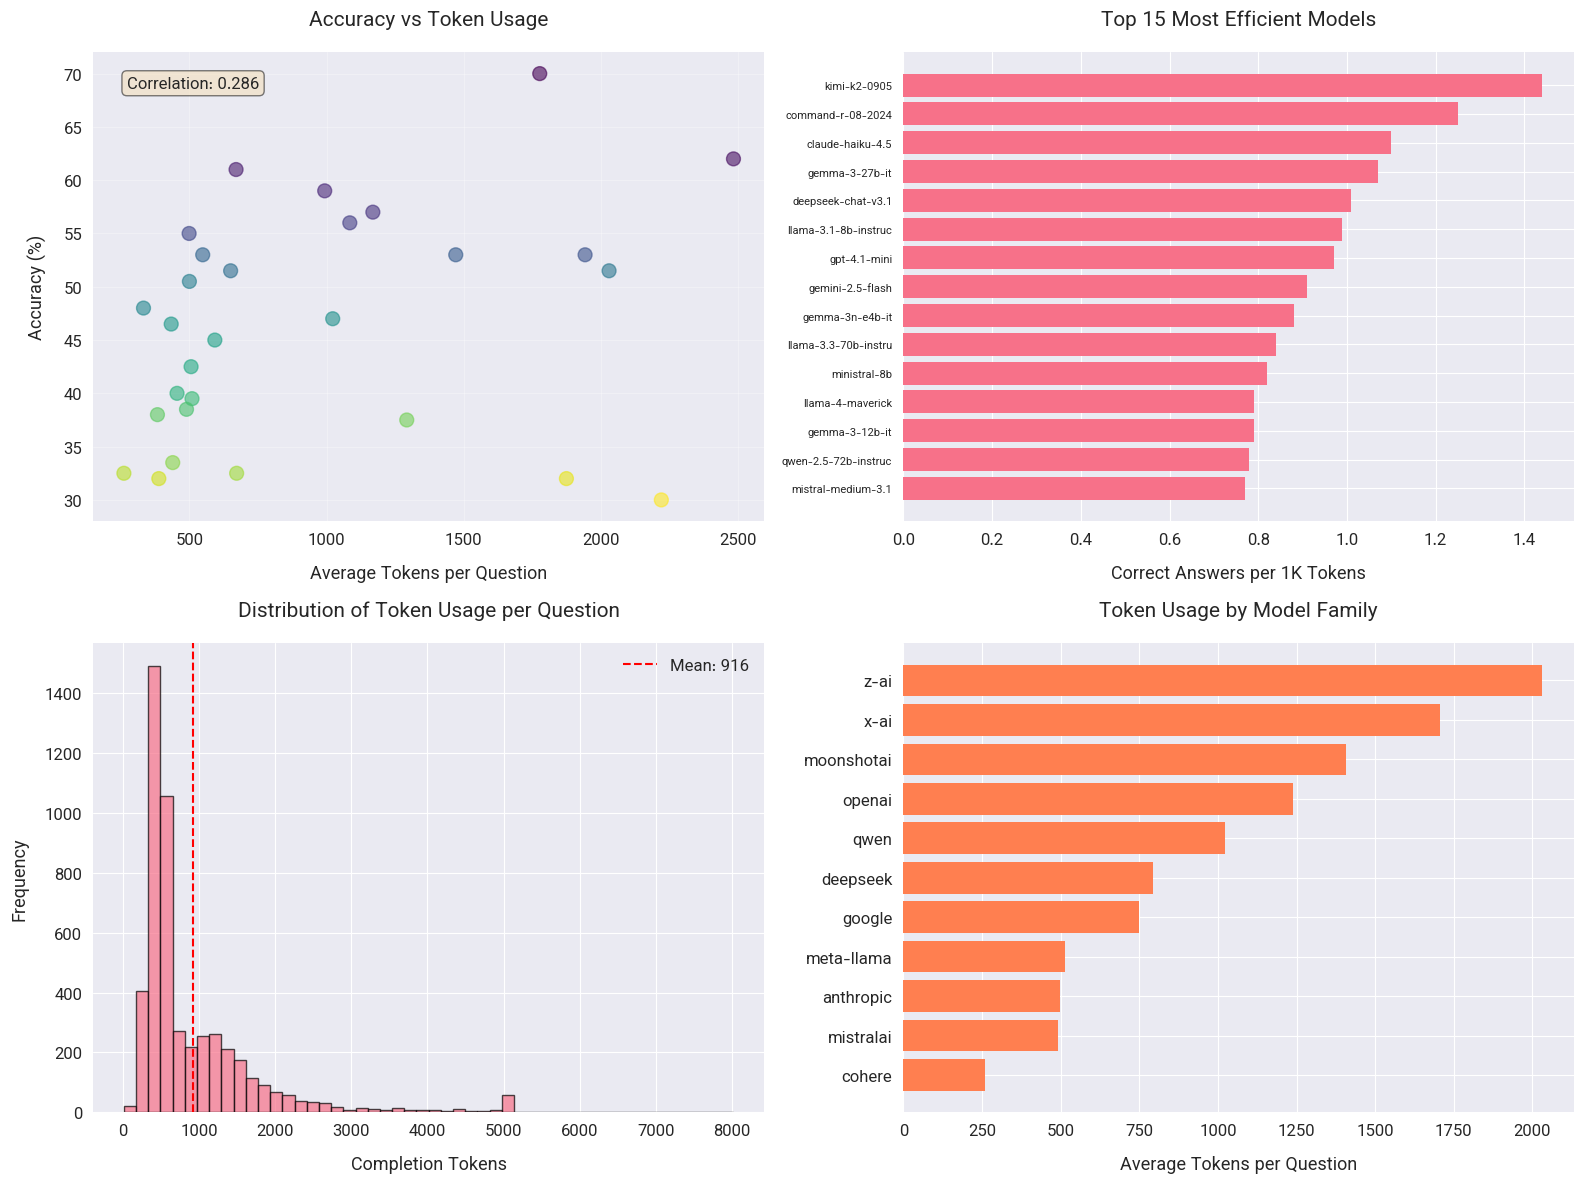


💡 Token Efficiency Insights:
Most efficient model: moonshotai/kimi-k2-0905
Correlation between tokens and accuracy: 0.286
➜ Weak correlation: Token usage doesn't strongly predict accuracy


In [7]:
# Analyze token usage vs accuracy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter: Accuracy vs Average Tokens
axes[0, 0].scatter(model_performance['avg_tokens_per_question'],
                   model_performance['accuracy_pct'],
                   alpha=0.6, s=100, c=range(len(model_performance)), cmap='viridis')
axes[0, 0].set_xlabel('Average Tokens per Question')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Accuracy vs Token Usage')
axes[0, 0].grid(True, alpha=0.3)

# Add correlation
corr = model_performance[['avg_tokens_per_question', 'accuracy_pct']].corr().iloc[0, 1]
axes[0, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Efficiency ranking
top_efficient = model_performance.nlargest(15, 'efficiency')
axes[0, 1].barh(range(len(top_efficient)), top_efficient['efficiency'])
axes[0, 1].set_yticks(range(len(top_efficient)))
axes[0, 1].set_yticklabels([name.split('/')[-1][:20] for name in top_efficient.index], fontsize=8)
axes[0, 1].set_xlabel('Correct Answers per 1K Tokens')
axes[0, 1].set_title('Top 15 Most Efficient Models')
axes[0, 1].invert_yaxis()

# Token distribution
axes[1, 0].hist(results_df['completion_tokens'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Completion Tokens')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Token Usage per Question')
axes[1, 0].axvline(results_df['completion_tokens'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['completion_tokens'].mean():.0f}")
axes[1, 0].legend()

# Tokens by family
token_by_family = model_performance.groupby('family')['avg_tokens_per_question'].mean().sort_values(ascending=False)
axes[1, 1].barh(range(len(token_by_family)), token_by_family.values, color='coral')
axes[1, 1].set_yticks(range(len(token_by_family)))
axes[1, 1].set_yticklabels(token_by_family.index)
axes[1, 1].set_xlabel('Average Tokens per Question')
axes[1, 1].set_title('Token Usage by Model Family')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n💡 Token Efficiency Insights:")
print(f"Most efficient model: {model_performance.nlargest(1, 'efficiency').index[0]}")
print(f"Correlation between tokens and accuracy: {corr:.3f}")
if corr > 0.3:
    print("➜ Moderate positive correlation: More tokens generally lead to better accuracy")
elif corr < -0.3:
    print("➜ Negative correlation: More tokens lead to worse accuracy (inefficiency)")
else:
    print("➜ Weak correlation: Token usage doesn't strongly predict accuracy")

## 3. Question Difficulty Analysis

**Overview:** Identifies which questions are hardest/easiest for models and analyzes what makes certain semantic distinctions challenging. Helps understand the limits of current LLM understanding of Persian poetry.

### 3.1 Identify Hard and Easy Questions

Which questions are most/least challenging across all models. Hard questions reveal semantic distinctions that even advanced models struggle with, while easy questions show widely understood concepts.

In [8]:
# Calculate difficulty metrics for each question
question_stats = results_df.groupby('question_id').agg({
    'is_correct': ['sum', 'count', 'mean', 'std'],
    'model_answer': lambda x: x.mode()[0] if len(x.mode()) > 0 else None,
    'correct_answer': 'first'
}).round(4)

question_stats.columns = ['correct_count', 'total_models', 'success_rate', 'std_dev', 'most_common_answer', 'correct_answer']
question_stats['success_rate_pct'] = (question_stats['success_rate'] * 100).round(2)
question_stats['difficulty_score'] = 100 - question_stats['success_rate_pct']  # Higher = harder

# Categorize difficulty
def categorize_difficulty(success_rate):
    if success_rate >= 0.7:
        return 'Easy'
    elif success_rate >= 0.5:
        return 'Medium'
    elif success_rate >= 0.3:
        return 'Hard'
    else:
        return 'Very Hard'

question_stats['difficulty_category'] = question_stats['success_rate'].apply(categorize_difficulty)
question_stats = question_stats.sort_values('success_rate', ascending=True)

print("\n📉 10 Hardest Questions (Lowest Success Rate):")
print(question_stats[['success_rate_pct', 'correct_count', 'total_models', 'correct_answer', 'most_common_answer']].head(10))

print("\n📈 10 Easiest Questions (Highest Success Rate):")
print(question_stats[['success_rate_pct', 'correct_count', 'total_models', 'correct_answer', 'most_common_answer']].tail(10))

print("\n📊 Difficulty Distribution:")
print(question_stats['difficulty_category'].value_counts().sort_index())


📉 10 Hardest Questions (Lowest Success Rate):
             success_rate_pct  correct_count  total_models  correct_answer  \
question_id                                                                  
458                       0.0              0            21               3   
307                       0.0              0            21               2   
472                       0.0              0            21               3   
319                       0.0              0            21               4   
275                       0.0              0            29               2   
487                       0.0              0            21               3   
352                       0.0              0            21               3   
429                       0.0              0            21               3   
229                       0.0              0            29               3   
305                       0.0              0            21               2   

             mos

### 3.2 Visualize Question Difficulty

Distribution of question difficulty across the dataset. Shows whether most questions are hard, easy, or medium, and how success rates are distributed.

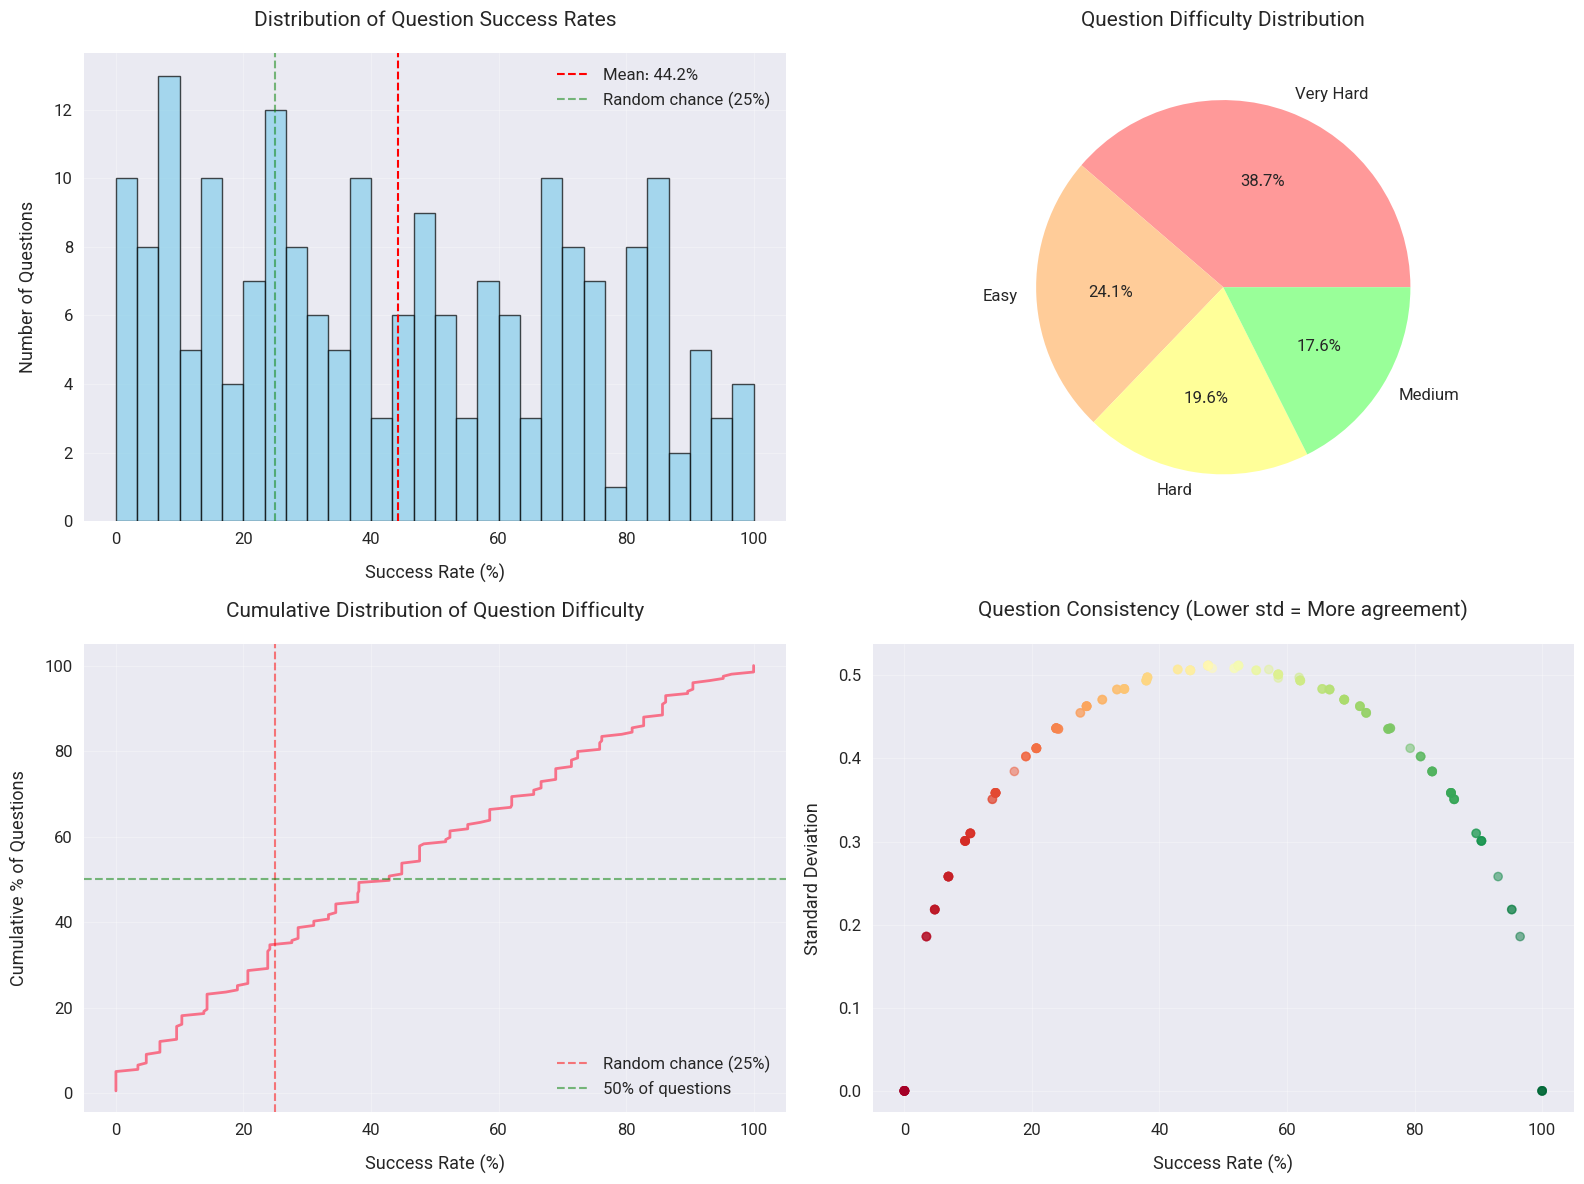


📊 Question Difficulty Statistics:
Mean success rate: 44.23%
Median success rate: 42.86%
Questions above random chance (25%): 130 (65.3%)
Questions with >50% success: 83 (41.7%)


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Success rate distribution
axes[0, 0].hist(question_stats['success_rate_pct'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(question_stats['success_rate_pct'].mean(), color='red', linestyle='--',
                   label=f"Mean: {question_stats['success_rate_pct'].mean():.1f}%")
axes[0, 0].axvline(25, color='green', linestyle='--', alpha=0.5, label='Random chance (25%)')
axes[0, 0].set_xlabel('Success Rate (%)')
axes[0, 0].set_ylabel('Number of Questions')
axes[0, 0].set_title('Distribution of Question Success Rates')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Difficulty categories pie chart
difficulty_counts = question_stats['difficulty_category'].value_counts()
axes[0, 1].pie(difficulty_counts.values, labels=difficulty_counts.index, autopct='%1.1f%%',
               colors=['#ff9999', '#ffcc99', '#ffff99', '#99ff99'])
axes[0, 1].set_title('Question Difficulty Distribution')

# Cumulative distribution
sorted_success = np.sort(question_stats['success_rate_pct'])
cumulative = np.arange(1, len(sorted_success) + 1) / len(sorted_success) * 100
axes[1, 0].plot(sorted_success, cumulative, linewidth=2)
axes[1, 0].axvline(25, color='red', linestyle='--', alpha=0.5, label='Random chance (25%)')
axes[1, 0].axhline(50, color='green', linestyle='--', alpha=0.5, label='50% of questions')
axes[1, 0].set_xlabel('Success Rate (%)')
axes[1, 0].set_ylabel('Cumulative % of Questions')
axes[1, 0].set_title('Cumulative Distribution of Question Difficulty')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Standard deviation vs success rate
axes[1, 1].scatter(question_stats['success_rate_pct'], question_stats['std_dev'],
                   alpha=0.5, c=question_stats['success_rate_pct'], cmap='RdYlGn')
axes[1, 1].set_xlabel('Success Rate (%)')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_title('Question Consistency (Lower std = More agreement)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Question Difficulty Statistics:")
print(f"Mean success rate: {question_stats['success_rate_pct'].mean():.2f}%")
print(f"Median success rate: {question_stats['success_rate_pct'].median():.2f}%")
print(f"Questions above random chance (25%): {(question_stats['success_rate_pct'] > 25).sum()} ({(question_stats['success_rate_pct'] > 25).sum() / len(question_stats) * 100:.1f}%)")
print(f"Questions with >50% success: {(question_stats['success_rate_pct'] > 50).sum()} ({(question_stats['success_rate_pct'] > 50).sum() / len(question_stats) * 100:.1f}%)")

### 3.3 Analyze Hardest Questions in Detail

Deep dive into the 5 most challenging questions with full Persian text and answer distributions. Helps understand what specific semantic patterns confuse models.

In [10]:
# Examine the 5 hardest questions
hardest_questions = question_stats.nsmallest(5, 'success_rate')

print("\n🔍 Detailed Analysis of 5 Hardest Questions:\n")
for idx, (q_id, row) in enumerate(hardest_questions.iterrows(), 1):
    print(f"{'='*80}")
    print(f"Question #{idx}: ID {q_id}")
    print(f"Success Rate: {row['success_rate_pct']:.1f}% ({row['correct_count']:.0f}/{row['total_models']:.0f} models)")
    print(f"Correct Answer: {row['correct_answer']}")
    print(f"Most Common Answer: {row['most_common_answer']}")

    # Get answer distribution for this question
    q_answers = results_df[results_df['question_id'] == q_id]['model_answer'].value_counts()
    print(f"\nAnswer Distribution:")
    for ans, count in q_answers.items():
        marker = " ✓ CORRECT" if ans == row['correct_answer'] else ""
        print(f"  Option {ans}: {count} models ({count/row['total_models']*100:.1f}%){marker}")

    # Show question content if available
    if q_id in questions_dict:
        q_data = questions_dict[q_id]
        print(f"\nQuestion Stem: {q_data['stem']}")
        print(f"\nOptions:")
        for opt in sorted(q_data['options'], key=lambda x: x['label']):
            marker = " ✓" if opt['label'] == row['correct_answer'] else ""
            print(f"  {opt['label']}. {opt['mesra1']} - {opt['mesra2']}{marker}")
    print()


🔍 Detailed Analysis of 5 Hardest Questions:

Question #1: ID 458
Success Rate: 0.0% (0/21 models)
Correct Answer: 3
Most Common Answer: 2.0

Answer Distribution:
  Option 2.0: 21 models (100.0%)

Question Stem: مفهوم بیت من آزاده از خاک آزادگانم گُلِ صبر می پرورد دامن من از کدام گزینه دورتر است؟

Options:
  1. ز دانش روان ها پر از رامش است - برِ ما شکیبایی و دانش است
  2. وی همه آزادگی ز طبع تو پیدا - ای همه ناراستی ز کلک (قلم) تو پنهان
  3. همه دانند که در صحبت گل خاری هست - صبر بر جور رقیبت چه کنم گر نکنم ✓
  4. شکیبایی و دوری پیشه می کرد - ز خلق آن ماه چون اندیشه می کرد

Question #2: ID 307
Success Rate: 0.0% (0/21 models)
Correct Answer: 2
Most Common Answer: 4.0

Answer Distribution:
  Option 4.0: 14 models (66.7%)
  Option 1.0: 4 models (19.0%)
  Option 3.0: 2 models (9.5%)

Question Stem: مفاهیم عبارت چون بخواستیم رفت ما را به انعام و اکرام به راه دریا گسیل کرد چنان که در کرامت و فراغ به پارس رسیدیم از برکات آن آزاد مرد که خدای عَ زّ و جَ لّ از آزاد مردان خشنود باد در همه گزینه

## 4. Inter-Model Agreement Analysis

**Overview:** Examines how often models agree or disagree with each other. Reveals whether models converge on similar interpretations or use fundamentally different semantic understanding strategies.

### 4.1 Pairwise Model Agreement

How often pairs of models agree on answers, regardless of correctness. High agreement suggests models use similar reasoning strategies; low agreement reveals diverse approaches.

In [35]:
# Create a pivot table: rows = questions, columns = models, values = answers
answer_matrix = results_df.pivot_table(
    index='question_id',
    columns='model_name',
    values='model_answer',
    aggfunc='first'
)

# Calculate pairwise agreement between models
models = answer_matrix.columns
n_models = len(models)
agreement_matrix = np.zeros((n_models, n_models))

for i, model1 in enumerate(models):
    for j, model2 in enumerate(models):
        if i == j:
            agreement_matrix[i, j] = 100.0
        else:
            # Calculate percentage of questions where both models gave the same answer
            valid_mask = answer_matrix[model1].notna() & answer_matrix[model2].notna()
            if valid_mask.sum() > 0:
                agreement = (answer_matrix.loc[valid_mask, model1] == answer_matrix.loc[valid_mask, model2]).mean() * 100
                agreement_matrix[i, j] = agreement

# Create agreement dataframe
agreement_df = pd.DataFrame(agreement_matrix, index=models, columns=models)

print("\n🤝 Model Agreement Analysis:")
print(f"Mean pairwise agreement: {agreement_matrix[np.triu_indices_from(agreement_matrix, k=1)].mean():.2f}%")
print(f"Median pairwise agreement: {np.median(agreement_matrix[np.triu_indices_from(agreement_matrix, k=1)]):.2f}%")

# Find most and least agreeable model pairs
np.fill_diagonal(agreement_matrix, 0)  # Ignore self-agreement
max_agreement_idx = np.unravel_index(agreement_matrix.argmax(), agreement_matrix.shape)
min_agreement_idx = np.unravel_index(agreement_matrix[agreement_matrix > 0].argmin(), agreement_matrix.shape)

print(f"\nMost similar models: {models[max_agreement_idx[0]]} ↔ {models[max_agreement_idx[1]]}")
print(f"  Agreement: {agreement_matrix[max_agreement_idx]:.2f}%")
print(f"\nLeast similar models: {models[min_agreement_idx[0]]} ↔ {models[min_agreement_idx[1]]}")
print(f"  Agreement: {agreement_matrix[min_agreement_idx]:.2f}%")

# Flatten upper triangle into list of (model1, model2, agreement)
pairs = []
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        pairs.append((models[i], models[j], agreement_matrix[i, j]))

# Sort by agreement (descending)
sorted_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\n📊 Agreement order (highest → lowest):")
for m1, m2, score in sorted_pairs:
    print(f"{m1} ↔ {m2}: {score:.2f}%")

# Identify most and least similar models
most_agree = sorted_pairs[0]
least_agree = sorted_pairs[-1]


🤝 Model Agreement Analysis:
Mean pairwise agreement: 51.04%
Median pairwise agreement: 50.38%

Most similar models: google/gemini-2.5-flash ↔ google/gemini-2.5-pro
  Agreement: 78.79%

Least similar models: mistralai/ministral-8b ↔ deepseek/deepseek-chat-v3.1
  Agreement: 40.20%

📊 Agreement order (highest → lowest):
google/gemini-2.5-flash ↔ google/gemini-2.5-pro: 78.79%
openai/gpt-4.1-mini ↔ x-ai/grok-3-mini: 73.74%
google/gemini-2.5-flash ↔ moonshotai/kimi-k2-thinking: 72.53%
google/gemini-2.5-flash ↔ qwen/qwen3-max: 71.72%
moonshotai/kimi-k2-thinking ↔ x-ai/grok-4-fast: 71.43%
google/gemini-2.5-flash ↔ openai/gpt-4.1-mini: 70.71%
meta-llama/llama-4-maverick ↔ openai/gpt-4.1-mini: 70.71%
openai/gpt-5-mini ↔ x-ai/grok-3-mini: 70.71%
openai/gpt-5-mini ↔ x-ai/grok-4-fast: 70.71%
moonshotai/kimi-k2-thinking ↔ openai/gpt-5-mini: 70.33%
google/gemini-2.5-pro ↔ qwen/qwen3-max: 69.70%
qwen/qwen3-max ↔ x-ai/grok-4-fast: 69.70%
meta-llama/llama-4-maverick ↔ moonshotai/kimi-k2-thinking: 69.23

### 4.2 Visualize Model Agreement Heatmap

Visual matrix of which models behave similarly. Helps identify model clusters and whether different architectures lead to different interpretation strategies.

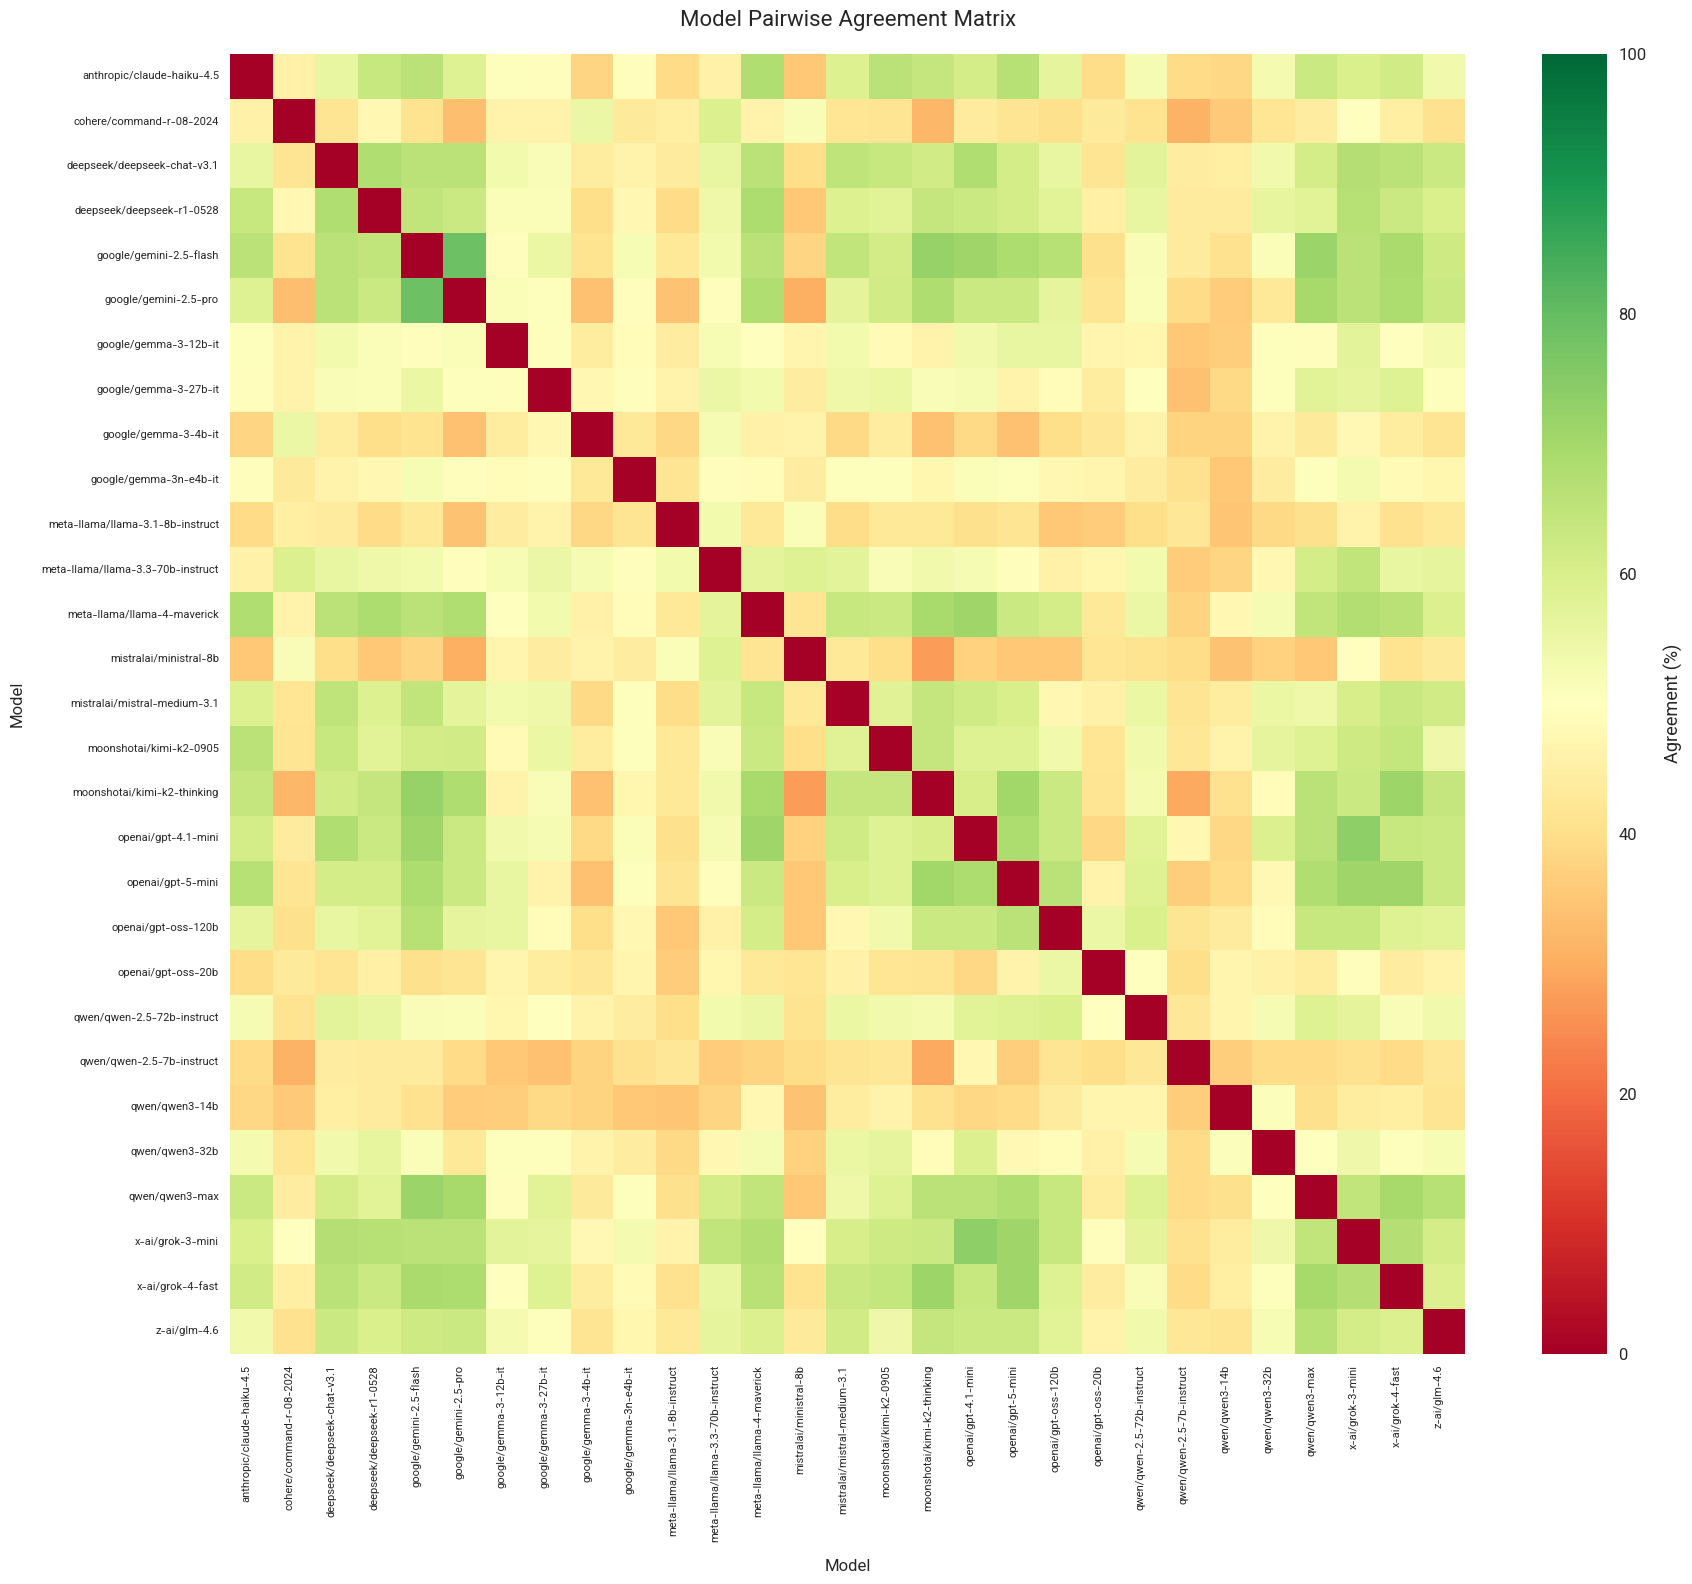

In [12]:
# Plot agreement heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(agreement_df, annot=False, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Agreement (%)'})
plt.title('Model Pairwise Agreement Matrix', fontsize=16, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Consensus Analysis

How often models collectively agree on an answer. High consensus with correct answers indicates clear semantic distinctions; low consensus suggests ambiguous or nuanced questions.


📊 Consensus Statistics:
Mean consensus rate: 63.92%
Questions with >50% consensus: 141 (70.9%)
Questions where majority was correct: 105 (52.8%)
Mean answer diversity: 3.31 unique answers per question


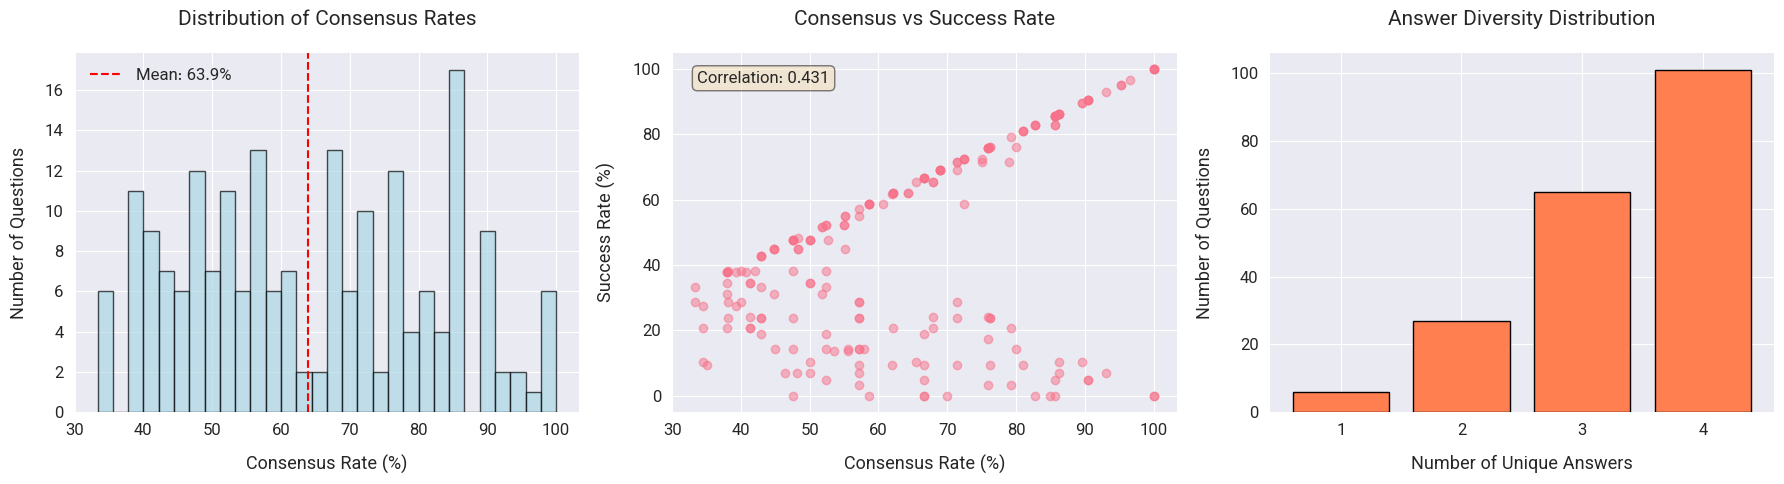

In [13]:
# Calculate consensus for each question
def calculate_consensus_metrics(row):
    answers = row.dropna().values
    if len(answers) == 0:
        return pd.Series({'consensus_rate': 0, 'majority_answer': None, 'diversity': 0})

    answer_counts = pd.Series(answers).value_counts()
    majority_answer = answer_counts.index[0]
    consensus_rate = answer_counts.iloc[0] / len(answers) * 100
    diversity = len(answer_counts)  # Number of unique answers

    return pd.Series({
        'consensus_rate': consensus_rate,
        'majority_answer': majority_answer,
        'diversity': diversity
    })

consensus_stats = answer_matrix.apply(calculate_consensus_metrics, axis=1)
consensus_stats = consensus_stats.join(question_stats[['correct_answer', 'success_rate_pct']])
consensus_stats['majority_correct'] = consensus_stats['majority_answer'] == consensus_stats['correct_answer']

print("\n📊 Consensus Statistics:")
print(f"Mean consensus rate: {consensus_stats['consensus_rate'].mean():.2f}%")
print(f"Questions with >50% consensus: {(consensus_stats['consensus_rate'] > 50).sum()} ({(consensus_stats['consensus_rate'] > 50).sum() / len(consensus_stats) * 100:.1f}%)")
print(f"Questions where majority was correct: {consensus_stats['majority_correct'].sum()} ({consensus_stats['majority_correct'].sum() / len(consensus_stats) * 100:.1f}%)")
print(f"Mean answer diversity: {consensus_stats['diversity'].mean():.2f} unique answers per question")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Consensus rate distribution
axes[0].hist(consensus_stats['consensus_rate'], bins=30, edgecolor='black', alpha=0.7, color='lightblue')
axes[0].set_xlabel('Consensus Rate (%)')
axes[0].set_ylabel('Number of Questions')
axes[0].set_title('Distribution of Consensus Rates')
axes[0].axvline(consensus_stats['consensus_rate'].mean(), color='red', linestyle='--',
                label=f"Mean: {consensus_stats['consensus_rate'].mean():.1f}%")
axes[0].legend()

# Consensus vs Success Rate
axes[1].scatter(consensus_stats['consensus_rate'], consensus_stats['success_rate_pct'], alpha=0.5)
axes[1].set_xlabel('Consensus Rate (%)')
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Consensus vs Success Rate')
corr = consensus_stats[['consensus_rate', 'success_rate_pct']].corr().iloc[0, 1]
axes[1].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Diversity distribution
diversity_counts = consensus_stats['diversity'].value_counts().sort_index()
axes[2].bar(diversity_counts.index, diversity_counts.values, color='coral', edgecolor='black')
axes[2].set_xlabel('Number of Unique Answers')
axes[2].set_ylabel('Number of Questions')
axes[2].set_title('Answer Diversity Distribution')
axes[2].set_xticks(range(1, 5))

plt.tight_layout()
plt.show()

## 5. Answer Distribution and Bias Analysis

**Overview:** Detects systematic biases in model responses. Shows if models have tendencies to favor certain answer positions regardless of content, which indicates flawed reasoning patterns.

### 5.1 Overall Answer Distribution

Whether models have systematic biases toward certain answer options (e.g., always choosing option 4). Compares model answer distribution to the actual distribution of correct answers.

In [14]:
# Analyze answer distribution
print("\n📊 Answer Distribution Analysis:\n")

# Correct answer distribution
correct_answer_dist = results_df['correct_answer'].value_counts().sort_index()
print("Distribution of Correct Answers in Dataset:")
for ans, count in correct_answer_dist.items():
    print(f"  Option {ans}: {count} ({count/len(results_df)*100:.1f}%)")

# Model answer distribution
model_answer_dist = results_df['model_answer'].value_counts().sort_index()
print("\nDistribution of Model Answers (All Models Combined):")
for ans, count in model_answer_dist.items():
    print(f"  Option {ans}: {count} ({count/len(results_df.dropna(subset=['model_answer']))*100:.1f}%)")

# Check for bias
expected_freq = 25.0  # Random chance
print("\n🎯 Answer Bias Detection:")
for ans in [1, 2, 3, 4]:
    actual_freq = (results_df['model_answer'] == ans).sum() / len(results_df.dropna(subset=['model_answer'])) * 100
    bias = actual_freq - expected_freq
    direction = "overselected" if bias > 5 else "underselected" if bias < -5 else "balanced"
    print(f"  Option {ans}: {actual_freq:.1f}% ({direction}, bias: {bias:+.1f}%)")


📊 Answer Distribution Analysis:

Distribution of Correct Answers in Dataset:
  Option 1: 982 (19.6%)
  Option 2: 1298 (26.0%)
  Option 3: 1284 (25.7%)
  Option 4: 1436 (28.7%)

Distribution of Model Answers (All Models Combined):
  Option 1.0: 1000 (20.2%)
  Option 2.0: 1137 (23.0%)
  Option 3.0: 1050 (21.2%)
  Option 4.0: 1760 (35.6%)

🎯 Answer Bias Detection:
  Option 1: 20.2% (balanced, bias: -4.8%)
  Option 2: 23.0% (balanced, bias: -2.0%)
  Option 3: 21.2% (balanced, bias: -3.8%)
  Option 4: 35.6% (overselected, bias: +10.6%)


### 5.2 Model-Specific Answer Bias

Which models have the strongest positional biases (e.g., over-selecting certain options). A balanced model should select all options roughly equally when considering the whole dataset.


⚖️ Models with Highest Answer Bias:
model_answer                       bias_score          1          2  \
meta-llama/llama-3.3-70b-instruct   20.081086  12.500000  10.500000   
cohere/command-r-08-2024            20.034346  10.000000  15.500000   
mistralai/ministral-8b              18.934096  10.000000  12.000000   
google/gemma-3-4b-it                12.908601  24.352332  17.098446   
meta-llama/llama-3.1-8b-instruct    12.020815  13.000000  20.000000   
google/gemma-3-27b-it               11.575837  27.000000  17.000000   
google/gemma-3-12b-it               10.295630  17.000000  27.000000   
qwen/qwen-2.5-7b-instruct            9.598177  12.500000  21.500000   
x-ai/grok-3-mini                     8.595057  20.000000  23.000000   
anthropic/claude-haiku-4.5           7.582875  18.000000  37.000000   

model_answer                               3         4  
meta-llama/llama-3.3-70b-instruct  17.500000  59.50000  
cohere/command-r-08-2024           15.000000  59.50000  
mistralai/

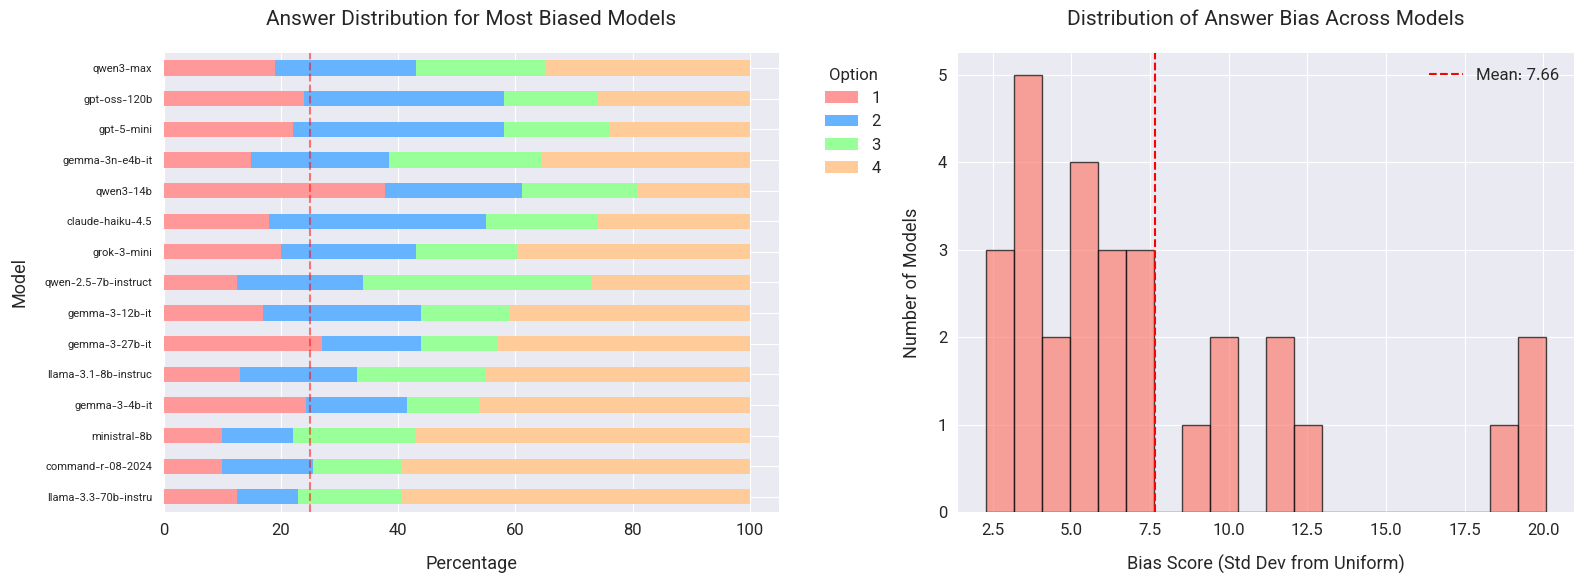

In [15]:
# Calculate answer distribution per model
model_answer_bias = pd.DataFrame()
for model in results_df['model_name'].unique():
    model_data = results_df[results_df['model_name'] == model]
    answer_dist = model_data['model_answer'].value_counts(normalize=True).reindex([1, 2, 3, 4], fill_value=0) * 100
    model_answer_bias[model] = answer_dist

model_answer_bias = model_answer_bias.T

# Calculate bias score (std dev from uniform distribution)
model_answer_bias['bias_score'] = model_answer_bias.apply(lambda row: np.std([row[1], row[2], row[3], row[4]]), axis=1)
model_answer_bias = model_answer_bias.sort_values('bias_score', ascending=False)

print("\n⚖️ Models with Highest Answer Bias:")
print(model_answer_bias[['bias_score', 1, 2, 3, 4]].head(10))

print("\n⚖️ Models with Lowest Answer Bias (Most Balanced):")
print(model_answer_bias[['bias_score', 1, 2, 3, 4]].tail(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart for top biased models
top_biased = model_answer_bias.nlargest(15, 'bias_score')[[1, 2, 3, 4]]
top_biased.plot(kind='barh', stacked=True, ax=axes[0],
                color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[0].set_xlabel('Percentage')
axes[0].set_ylabel('Model')
axes[0].set_title('Answer Distribution for Most Biased Models')
axes[0].legend(title='Option', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_yticklabels([name.split('/')[-1][:20] for name in top_biased.index], fontsize=8)
axes[0].axvline(25, color='red', linestyle='--', alpha=0.5, label='Random chance (25%)')

# Bias score distribution
axes[1].hist(model_answer_bias['bias_score'], bins=20, edgecolor='black', alpha=0.7, color='salmon')
axes[1].set_xlabel('Bias Score (Std Dev from Uniform)')
axes[1].set_ylabel('Number of Models')
axes[1].set_title('Distribution of Answer Bias Across Models')
axes[1].axvline(model_answer_bias['bias_score'].mean(), color='red', linestyle='--',
                label=f"Mean: {model_answer_bias['bias_score'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix Analysis

When the correct answer is X, which wrong answer do models most often choose? Reveals systematic misinterpretation patterns and option confusion.

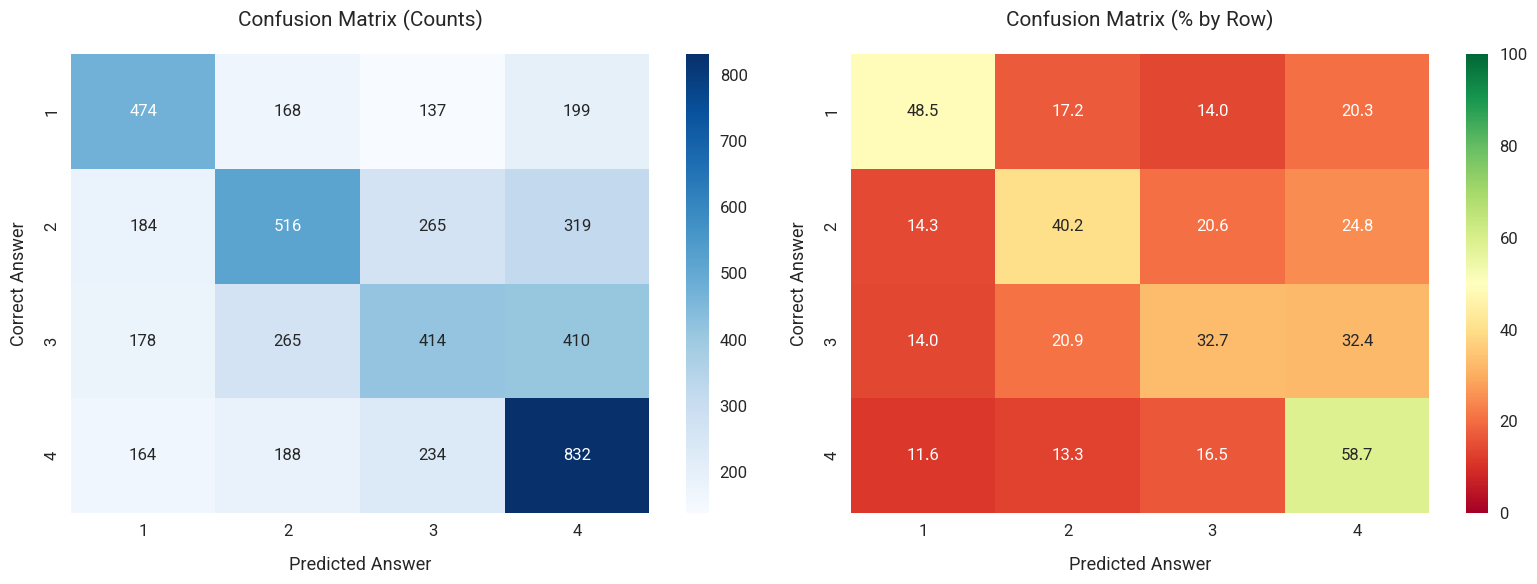


🎯 Confusion Matrix Insights:

When correct answer is 1:
  Accuracy: 48.5%
  Most common mistake: Choosing option 4 (20.3% of the time)

When correct answer is 2:
  Accuracy: 40.2%
  Most common mistake: Choosing option 4 (24.8% of the time)

When correct answer is 3:
  Accuracy: 32.7%
  Most common mistake: Choosing option 4 (32.4% of the time)

When correct answer is 4:
  Accuracy: 58.7%
  Most common mistake: Choosing option 3 (16.5% of the time)


In [16]:
# Overall confusion matrix
valid_responses = results_df.dropna(subset=['model_answer', 'correct_answer'])
cm = confusion_matrix(valid_responses['correct_answer'], valid_responses['model_answer'], labels=[1, 2, 3, 4])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
axes[0].set_xlabel('Predicted Answer')
axes[0].set_ylabel('Correct Answer')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4], vmin=0, vmax=100)
axes[1].set_xlabel('Predicted Answer')
axes[1].set_ylabel('Correct Answer')
axes[1].set_title('Confusion Matrix (% by Row)')

plt.tight_layout()
plt.show()

print("\n🎯 Confusion Matrix Insights:")
for i in range(4):
    correct_ans = i + 1
    accuracy = cm_normalized[i, i]
    print(f"\nWhen correct answer is {correct_ans}:")
    print(f"  Accuracy: {accuracy:.1f}%")
    # Find most common wrong answer
    wrong_answers = [(j+1, cm_normalized[i, j]) for j in range(4) if j != i]
    most_common_wrong = max(wrong_answers, key=lambda x: x[1])
    print(f"  Most common mistake: Choosing option {most_common_wrong[0]} ({most_common_wrong[1]:.1f}% of the time)")

## 6. Statistical Significance Analysis

**Overview:** Rigorous statistical testing to determine which performance differences are real versus due to random chance. Provides scientific confidence in model comparisons.

### 6.1 Performance Above Random Chance

Statistical test to determine if each model performs significantly better than random guessing (25%). Models that fail this test are not learning meaningful semantic patterns.

In [17]:
# Test if each model performs significantly better than random chance (25%)
from scipy.stats import binomtest

significance_results = []
for model in model_performance.index:
    correct = model_performance.loc[model, 'correct_count']
    total = model_performance.loc[model, 'total_questions']
    accuracy = model_performance.loc[model, 'accuracy']

    # Binomial test: H0 = model is guessing randomly (p=0.25)
    result = binomtest(int(correct), int(total), 0.25, alternative='greater')
    p_value = result.pvalue

    significance_results.append({
        'model': model,
        'accuracy': accuracy * 100,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'significance_level': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    })

sig_df = pd.DataFrame(significance_results).sort_values('accuracy', ascending=False)

print("\n📈 Statistical Significance Test (vs Random Chance 25%):\n")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant\n")
print(sig_df.head(15).to_string(index=False))

print(f"\n✅ Models significantly better than random: {sig_df['significant'].sum()} / {len(sig_df)}")
print(f"❌ Models not significantly better: {(~sig_df['significant']).sum()} / {len(sig_df)}")


📈 Statistical Significance Test (vs Random Chance 25%):

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant

                      model  accuracy      p_value  significant significance_level
      google/gemini-2.5-pro      70.0 4.374937e-21         True                ***
moonshotai/kimi-k2-thinking      62.0 5.950803e-15         True                ***
    google/gemini-2.5-flash      61.0 5.679308e-27         True                ***
             qwen/qwen3-max      59.0 5.892704e-13         True                ***
          openai/gpt-5-mini      57.0 1.029971e-11         True                ***
  deepseek/deepseek-r1-0528      56.0 4.055990e-11         True                ***
 anthropic/claude-haiku-4.5      55.0 1.535313e-10         True                ***
           x-ai/grok-4-fast      53.0 2.441582e-17         True                ***
           x-ai/grok-3-mini      53.0 2.441582e-17         True                ***
        openai/gpt-4.1-mini      53

### 6.2 Pairwise Model Comparisons

Whether performance differences between top models are statistically significant or just due to chance. Helps determine if one model is truly better than another.

In [18]:
# Compare top models pairwise using McNemar's test
try:
    from statsmodels.stats.contingency_tables import mcnemar
    has_mcnemar = True
except ImportError:
    print("⚠️  statsmodels not available. Skipping McNemar's test.")
    print("Install with: pip install statsmodels")
    has_mcnemar = False

if has_mcnemar:
    top_models = model_performance.nlargest(5, 'accuracy').index.tolist()

    print("\n🔬 Pairwise Statistical Comparison (McNemar's Test)")
    print("Compares if two models differ significantly in performance\n")

    for i in range(len(top_models)):
        for j in range(i+1, len(top_models)):
            model1 = top_models[i]
            model2 = top_models[j]

            # Get common questions
            m1_data = results_df[results_df['model_name'] == model1].set_index('question_id')
            m2_data = results_df[results_df['model_name'] == model2].set_index('question_id')

            common_qs = m1_data.index.intersection(m2_data.index)

            if len(common_qs) > 0:
                # Create contingency table: [both_correct, m1_correct_m2_wrong, m1_wrong_m2_correct, both_wrong]
                both_correct = ((m1_data.loc[common_qs, 'is_correct']) & (m2_data.loc[common_qs, 'is_correct'])).sum()
                m1_only = ((m1_data.loc[common_qs, 'is_correct']) & (~m2_data.loc[common_qs, 'is_correct'])).sum()
                m2_only = ((~m1_data.loc[common_qs, 'is_correct']) & (m2_data.loc[common_qs, 'is_correct'])).sum()
                both_wrong = ((~m1_data.loc[common_qs, 'is_correct']) & (~m2_data.loc[common_qs, 'is_correct'])).sum()

                # McNemar's test requires 2x2 table of form [[n00, n01], [n10, n11]]
                # where nij is count for (model1=i, model2=j)
                table = np.array([[both_wrong, m2_only], [m1_only, both_correct]])

                if m1_only + m2_only > 0:
                    result = mcnemar(table, exact=False, correction=True)
                    sig = "***" if result.pvalue < 0.001 else "**" if result.pvalue < 0.01 else "*" if result.pvalue < 0.05 else "ns"

                    acc1 = model_performance.loc[model1, 'accuracy_pct']
                    acc2 = model_performance.loc[model2, 'accuracy_pct']

                    print(f"\n{model1.split('/')[-1][:30]} ({acc1:.1f}%) vs")
                    print(f"{model2.split('/')[-1][:30]} ({acc2:.1f}%)")
                    print(f"  p-value: {result.pvalue:.4f} {sig}")
                    print(f"  Disagreement: {m1_only + m2_only} questions ({(m1_only + m2_only)/len(common_qs)*100:.1f}%)")
else:
    # Alternative simple comparison without McNemar's test
    top_models = model_performance.nlargest(5, 'accuracy').index.tolist()

    print("\n🔬 Pairwise Model Comparison (Simple Accuracy Difference)")
    print("Shows accuracy differences between top models\n")

    for i in range(len(top_models)):
        for j in range(i+1, len(top_models)):
            model1 = top_models[i]
            model2 = top_models[j]

            acc1 = model_performance.loc[model1, 'accuracy_pct']
            acc2 = model_performance.loc[model2, 'accuracy_pct']

            # Get common questions
            m1_data = results_df[results_df['model_name'] == model1].set_index('question_id')
            m2_data = results_df[results_df['model_name'] == model2].set_index('question_id')

            common_qs = m1_data.index.intersection(m2_data.index)

            if len(common_qs) > 0:
                m1_only = ((m1_data.loc[common_qs, 'is_correct']) & (~m2_data.loc[common_qs, 'is_correct'])).sum()
                m2_only = ((~m1_data.loc[common_qs, 'is_correct']) & (m2_data.loc[common_qs, 'is_correct'])).sum()

                print(f"\n{model1.split('/')[-1][:30]} ({acc1:.1f}%) vs")
                print(f"{model2.split('/')[-1][:30]} ({acc2:.1f}%)")
                print(f"  Accuracy difference: {abs(acc1 - acc2):.1f}%")
                print(f"  Disagreement: {m1_only + m2_only} questions ({(m1_only + m2_only)/len(common_qs)*100:.1f}%)")


🔬 Pairwise Statistical Comparison (McNemar's Test)
Compares if two models differ significantly in performance


gemini-2.5-pro (70.0%) vs
kimi-k2-thinking (62.0%)
  p-value: 0.1859 ns
  Disagreement: 28 questions (28.3%)

gemini-2.5-pro (70.0%) vs
gemini-2.5-flash (61.0%)
  p-value: 0.5023 ns
  Disagreement: 20 questions (20.2%)

gemini-2.5-pro (70.0%) vs
qwen3-max (59.0%)
  p-value: 0.0543 ns
  Disagreement: 27 questions (27.3%)

gemini-2.5-pro (70.0%) vs
gpt-5-mini (57.0%)
  p-value: 0.0425 *
  Disagreement: 35 questions (35.4%)

kimi-k2-thinking (62.0%) vs
gemini-2.5-flash (61.0%)
  p-value: 0.5403 ns
  Disagreement: 24 questions (24.2%)

kimi-k2-thinking (62.0%) vs
qwen3-max (59.0%)
  p-value: 0.7003 ns
  Disagreement: 27 questions (27.3%)

kimi-k2-thinking (62.0%) vs
gpt-5-mini (57.0%)
  p-value: 0.4237 ns
  Disagreement: 25 questions (25.3%)

gemini-2.5-flash (61.0%) vs
qwen3-max (59.0%)
  p-value: 0.2109 ns
  Disagreement: 23 questions (23.2%)

gemini-2.5-flash (61.0%) vs
gpt-5

## 7. Model Clustering and Similarity

**Overview:** Groups models based on behavioral similarity using clustering and dimensionality reduction. Reveals hidden patterns in how different model architectures approach semantic understanding.

### 7.1 Hierarchical Clustering of Models

Groups models by similar answer patterns into a tree structure. Models that cluster together make similar decisions, revealing architectural or training similarities.

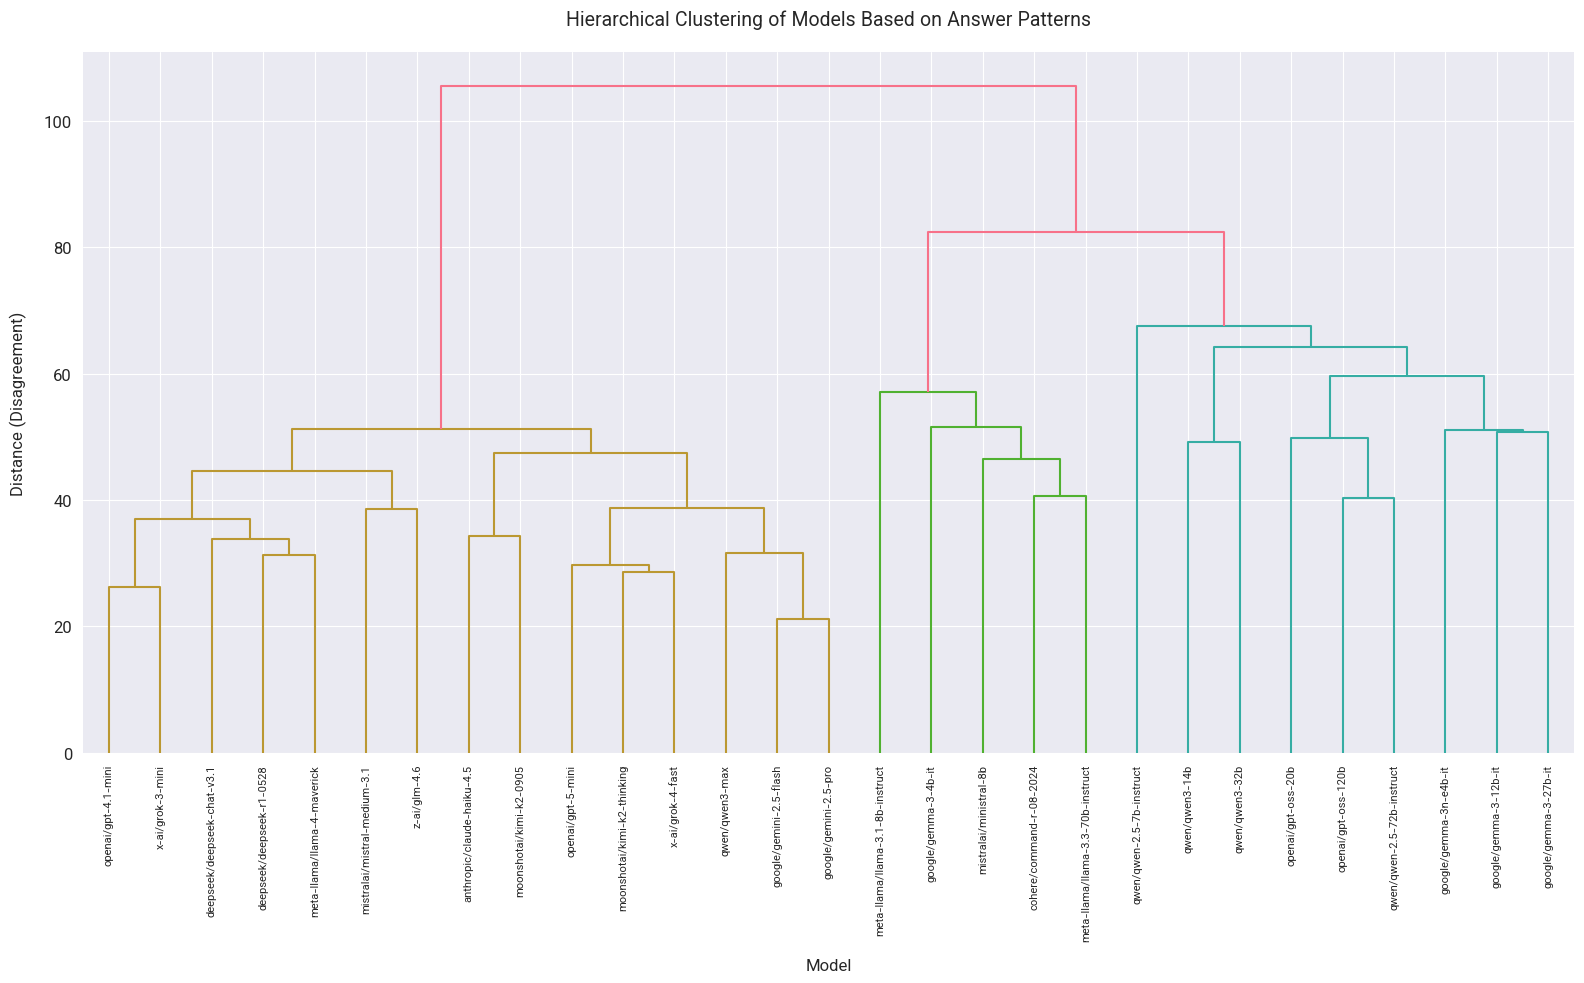


🌳 Clustering Insights:
Models that cluster together have similar answer patterns.
This reveals which models make similar decisions, regardless of correctness.


In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Use answer patterns to cluster models
# Create distance matrix based on disagreement
distance_matrix = 100 - agreement_matrix  # Convert agreement to distance
np.fill_diagonal(distance_matrix, 0)

# Perform hierarchical clustering
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 10))
dendrogram(linkage_matrix, labels=models, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering of Models Based on Answer Patterns', fontsize=14, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Distance (Disagreement)', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🌳 Clustering Insights:")
print("Models that cluster together have similar answer patterns.")
print("This reveals which models make similar decisions, regardless of correctness.")

### 7.2 PCA Visualization of Model Behavior

2D projection of model behavior space. Models close together in this space have similar semantic understanding patterns; distance indicates different interpretation approaches.

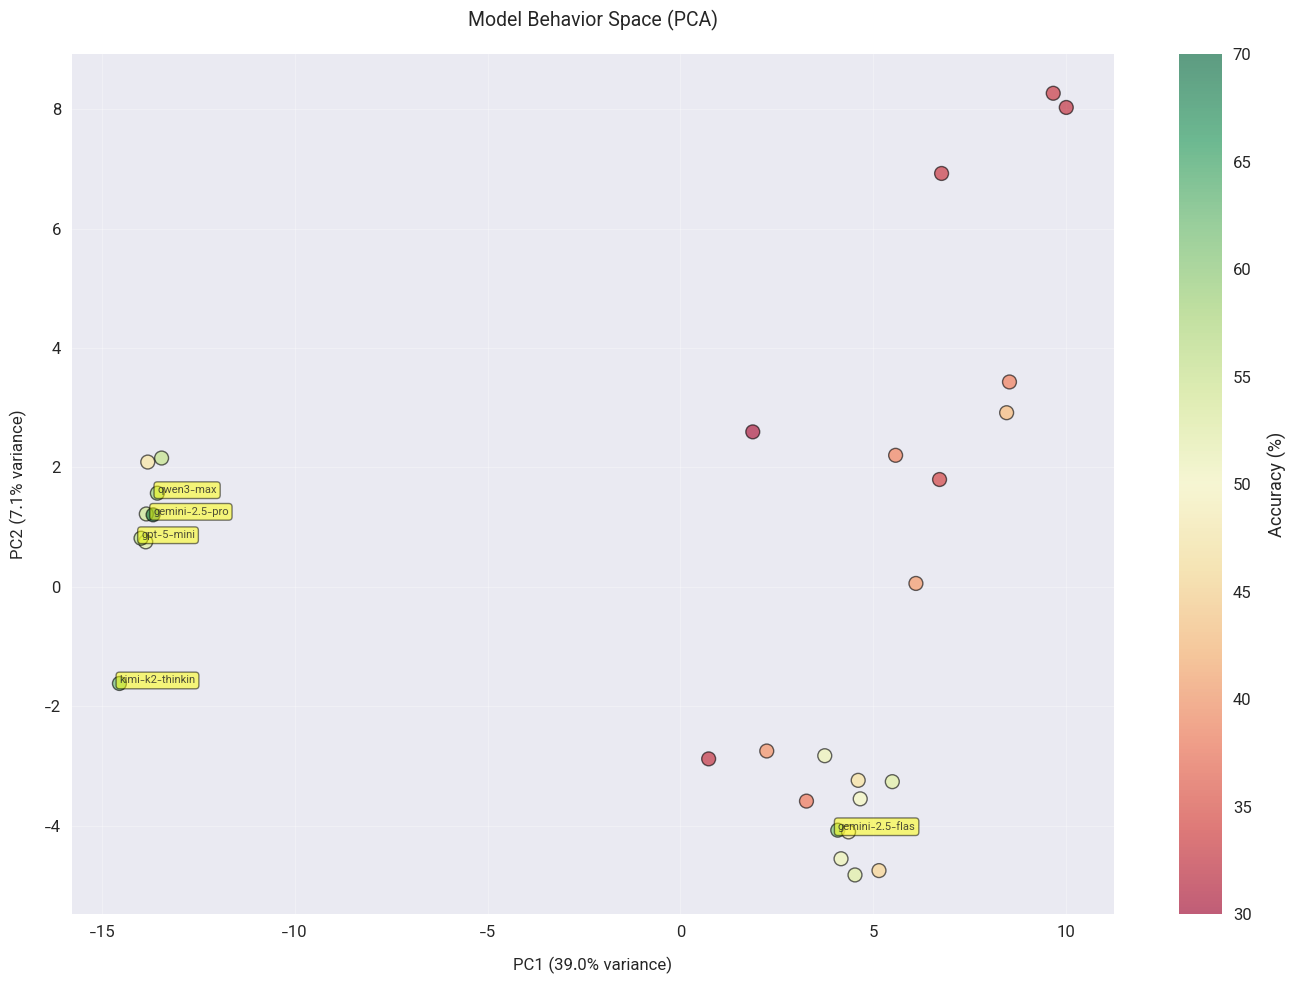


📊 PCA Explained Variance:
PC1: 38.95%
PC2: 7.05%
Total: 46.00%


In [20]:
# Prepare feature matrix: each model's answers to all questions
model_features = answer_matrix.T.fillna(0)  # Models as rows, questions as columns

# Apply PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(model_features)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'model': models,
    'accuracy': [model_performance.loc[m, 'accuracy_pct'] for m in models],
    'family': [model_performance.loc[m, 'family'] for m in models]
})

# Plot PCA
plt.figure(figsize=(14, 10))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['accuracy'], s=100, cmap='RdYlGn',
                     alpha=0.6, edgecolors='black', linewidth=1)
plt.colorbar(scatter, label='Accuracy (%)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Model Behavior Space (PCA)', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)

# Annotate top models
top_5_models = model_performance.nlargest(5, 'accuracy').index
for model in top_5_models:
    row = pca_df[pca_df['model'] == model].iloc[0]
    plt.annotate(model.split('/')[-1][:15], (row['PC1'], row['PC2']),
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n📊 PCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 8. Semantic Analysis: Persian Poetry Insights

**Overview:** Domain-specific analysis focusing on Persian poetry themes and cultural concepts. Identifies which poetic themes are most challenging and examines the quality of model reasoning about Persian literature.

### 8.1 Analyze Questions by Thematic Content

Performance breakdown by Persian poetry themes (love, spirituality, wisdom, etc.). Reveals which semantic domains are easier/harder for models to understand.


🎭 Performance by Thematic Content:

               mean_success_rate  median_success_rate  question_count  \
primary_theme                                                           
عشق و محبت                 37.93                31.52              30   
خدا و معنویت               37.94                42.86              15   
مرگ و فنا                  44.17                34.48               8   
قدرت و سلطنت               44.50                38.10              11   
دنیا و زندگی               44.62                44.83              27   
طبیعت                      45.63                47.62              64   
سایر                       45.68                44.83              25   
حکمت و دانایی              51.81                68.97              19   

               avg_difficulty  
primary_theme                  
عشق و محبت              62.07  
خدا و معنویت            62.06  
مرگ و فنا               55.83  
قدرت و سلطنت            55.50  
دنیا و زندگی            55.38  
طبیعت   

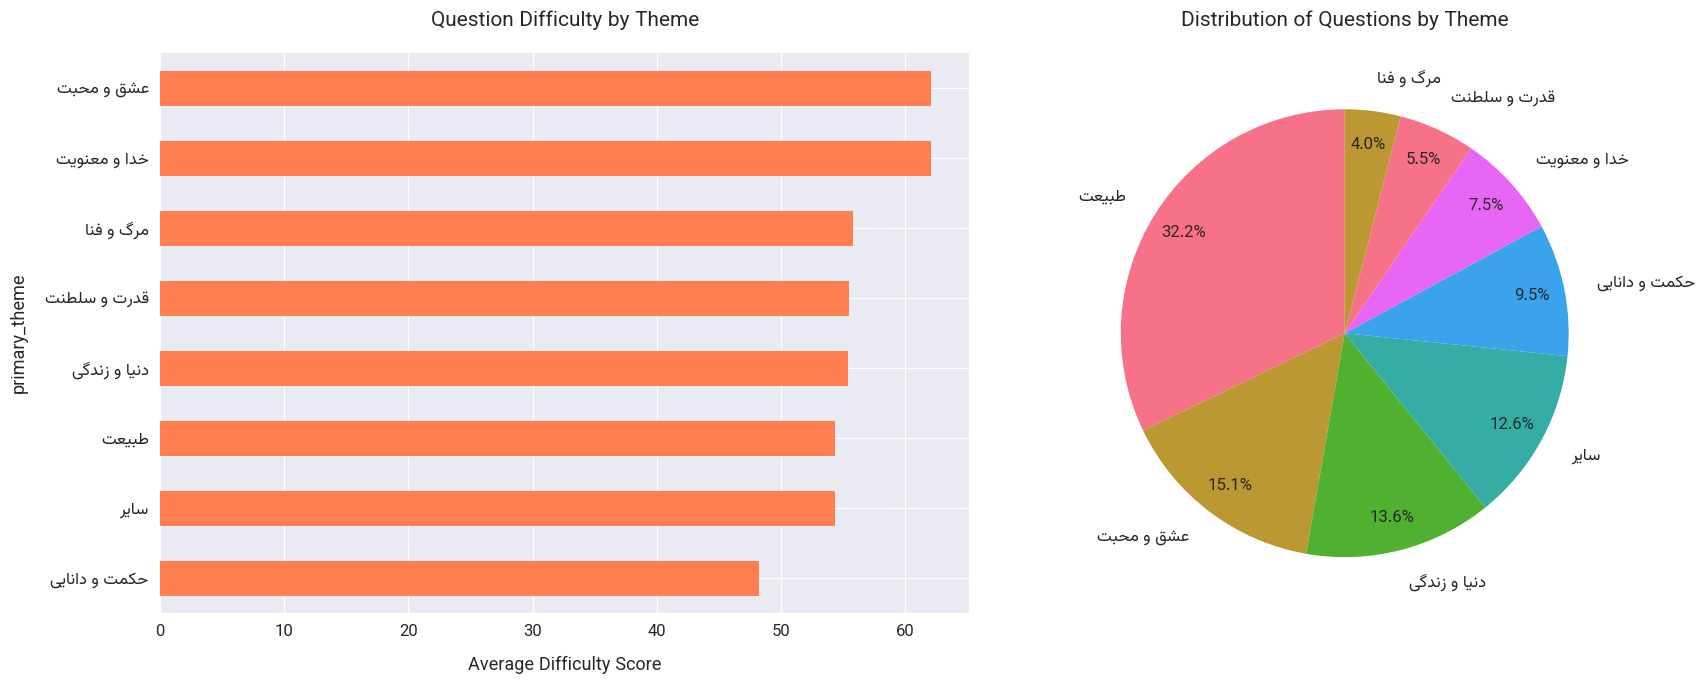

In [21]:
# Extract keywords from Persian poetry to categorize themes
# Common themes in Persian poetry
theme_keywords = {
    'عشق و محبت': ['عشق', 'محبت', 'عاشق', 'معشوق', 'دل', 'جان'],
    'خدا و معنویت': ['خدا', 'الله', 'حق', 'عفو', 'بخشایش', 'رحمت'],
    'دنیا و زندگی': ['دنیا', 'جهان', 'روزگار', 'زمانه', 'عمر', 'حیات'],
    'مرگ و فنا': ['مرگ', 'فنا', 'مردن', 'اجل', 'خاک'],
    'حکمت و دانایی': ['حکیم', 'دانش', 'خرد', 'عقل', 'فرزانه'],
    'قدرت و سلطنت': ['شاه', 'سلطان', 'پادشاه', 'تاج', 'تخت'],
    'طبیعت': ['گل', 'باغ', 'بهار', 'صحرا', 'دریا', 'آفتاب', 'ماه']
}

def extract_themes(question_data):
    """Extract themes from question options"""
    themes = set()

    # Combine all text from options
    all_text = ' '.join([opt['mesra1'] + ' ' + opt['mesra2'] for opt in question_data['options']])

    for theme, keywords in theme_keywords.items():
        if any(keyword in all_text for keyword in keywords):
            themes.add(theme)

    return list(themes) if themes else ['سایر']

# Apply theme extraction
question_themes = {}
for q_id, q_data in questions_dict.items():
    question_themes[q_id] = extract_themes(q_data)

# Add themes to question stats
question_stats['themes'] = question_stats.index.map(lambda x: ', '.join(question_themes.get(x, ['سایر'])))
question_stats['primary_theme'] = question_stats.index.map(lambda x: question_themes.get(x, ['سایر'])[0])

# Analyze difficulty by theme
theme_difficulty = question_stats.groupby('primary_theme').agg({
    'success_rate_pct': ['mean', 'median', 'count'],
    'difficulty_score': 'mean'
}).round(2)
theme_difficulty.columns = ['mean_success_rate', 'median_success_rate', 'question_count', 'avg_difficulty']
theme_difficulty = theme_difficulty.sort_values('avg_difficulty', ascending=False)

print("\n🎭 Performance by Thematic Content:\n")
print(theme_difficulty)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Theme difficulty
theme_difficulty['avg_difficulty'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_xlabel('Average Difficulty Score')
axes[0].set_title('Question Difficulty by Theme')
# Format Persian text in y-axis labels
formatted_labels = [format_persian_text(label) for label in theme_difficulty.index]
axes[0].set_yticklabels(formatted_labels)
axes[0].invert_yaxis()

# Theme distribution
theme_counts = question_stats['primary_theme'].value_counts()
# Format Persian text in pie chart labels
formatted_pie_labels = [format_persian_text(label) for label in theme_counts.index]
axes[1].pie(theme_counts.values,
            labels=formatted_pie_labels,
            autopct='%1.1f%%',
            startangle=90,
            labeldistance=1.15,  # Move labels farther from pie
            pctdistance=0.85)    # Position percentages better
axes[1].set_title('Distribution of Questions by Theme')

plt.tight_layout()
plt.show()

### 8.2 Reasoning Quality Analysis

Analyzes the quality of model reasoning/thinking processes. Examines whether longer or more analytical reasoning correlates with correct answers.

In [22]:
# Analyze reasoning outputs from models
reasoning_dir = Path('reasoning-outputs-improved')

if reasoning_dir.exists():
    reasoning_files = list(reasoning_dir.glob('*.json'))

    print(f"\n🧠 Reasoning Analysis ({len(reasoning_files)} reasoning outputs found)\n")

    reasoning_stats = []

    for file in reasoning_files[:100]:  # Sample first 100
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        model = data.get('model_id', '')
        q_id = data.get('question_id', '')
        reasoning_text = data.get('reasoning_text', '')

        if reasoning_text:
            # Simple metrics
            word_count = len(reasoning_text.split())
            has_analysis = any(keyword in reasoning_text.lower() for keyword in
                             ['option', 'couplet', 'concept', 'theme', 'meaning', 'analysis'])
            has_comparison = any(keyword in reasoning_text.lower() for keyword in
                               ['while', 'whereas', 'however', 'contrast', 'different', 'similar'])

            # Check if the model answered correctly
            model_response = results_df[
                (results_df['model_name'] == model) &
                (results_df['question_id'] == q_id)
            ]

            is_correct = model_response['is_correct'].iloc[0] if len(model_response) > 0 else None

            reasoning_stats.append({
                'model': model,
                'question_id': q_id,
                'word_count': word_count,
                'has_analysis': has_analysis,
                'has_comparison': has_comparison,
                'is_correct': is_correct
            })

    reasoning_df = pd.DataFrame(reasoning_stats)

    if len(reasoning_df) > 0:
        print("📊 Reasoning Quality Metrics:\n")
        print(f"Average reasoning length: {reasoning_df['word_count'].mean():.0f} words")
        print(f"Median reasoning length: {reasoning_df['word_count'].median():.0f} words")
        print(f"Responses with analysis keywords: {reasoning_df['has_analysis'].sum()} ({reasoning_df['has_analysis'].mean()*100:.1f}%)")
        print(f"Responses with comparison keywords: {reasoning_df['has_comparison'].sum()} ({reasoning_df['has_comparison'].mean()*100:.1f}%)")

        # Correlation between reasoning quality and correctness
        if reasoning_df['is_correct'].notna().sum() > 0:
            print("\n🎯 Reasoning Quality vs Correctness:")
            correct_with_analysis = reasoning_df[reasoning_df['has_analysis']]['is_correct'].mean()
            correct_without_analysis = reasoning_df[~reasoning_df['has_analysis']]['is_correct'].mean()
            print(f"Correct with analysis: {correct_with_analysis*100:.1f}%")
            print(f"Correct without analysis: {correct_without_analysis*100:.1f}%")

            correct_with_comparison = reasoning_df[reasoning_df['has_comparison']]['is_correct'].mean()
            correct_without_comparison = reasoning_df[~reasoning_df['has_comparison']]['is_correct'].mean()
            print(f"Correct with comparison: {correct_with_comparison*100:.1f}%")
            print(f"Correct without comparison: {correct_without_comparison*100:.1f}%")
else:
    print("\n⚠️ No reasoning outputs found")


🧠 Reasoning Analysis (1781 reasoning outputs found)

📊 Reasoning Quality Metrics:

Average reasoning length: 894 words
Median reasoning length: 623 words
Responses with analysis keywords: 90 (98.9%)
Responses with comparison keywords: 87 (95.6%)

🎯 Reasoning Quality vs Correctness:
Correct with analysis: 48.2%
Correct without analysis: nan%
Correct with comparison: 48.2%
Correct without comparison: 50.0%


## 9. Deep Persian Poetry Comprehension Analysis

This section analyzes how well models understand Persian poetry at a deeper semantic level, including:
- Metaphors and poetic devices
- Cultural and literary references
- Subtle semantic distinctions in Persian
- Error patterns specific to Persian language understanding

### 9.1 Persian Text Analysis - Hardest Questions

Let's examine the actual Persian text of questions models struggled with most:

In [23]:
# Display Persian text for hardest questions with full context
import json
from pathlib import Path

# Get hardest questions (already computed)
hardest_questions = question_stats.nsmallest(10, 'success_rate')

print("\n" + "="*80)
print("HARDEST QUESTIONS - FULL PERSIAN TEXT ANALYSIS")
print("="*80 + "\n")

for idx, (q_id, row) in enumerate(hardest_questions.iterrows(), 1):
    # Find question in dataset
    question_data = None
    for page in questions_data['pages']:
        for q in page['data']['questions']:
            if q['id'] == q_id:
                question_data = q
                break
        if question_data:
            break

    if not question_data:
        continue

    print(f"\n{'='*80}")
    print(f"Question #{idx}: ID {q_id}")
    print(f"Success Rate: {row['success_rate']:.1%} | Correct Answer: {answer_keys[str(q_id)]}")
    print(f"{'='*80}\n")

    # Display question stem
    print(f"سؤال: {question_data['stem']}")
    print("\n" + "-"*80 + "\n")

    # Display all options with Persian text
    correct_ans = answer_keys[str(q_id)]
    for opt in question_data['options']:
        marker = "✓ CORRECT" if opt['label'] == correct_ans else ""
        print(f"گزینه {opt['label']}: {marker}")
        print(f"  {opt['mesra1']}")
        print(f"  {opt['mesra2']}")
        print()

    # Show what models chose
    q_answers = results_df[results_df['question_id'] == q_id]
    answer_dist = q_answers['model_answer'].value_counts().sort_index()
    print("Model answers distribution:")
    for ans, count in answer_dist.items():
        pct = count / len(q_answers) * 100
        marker = "✓" if ans == correct_ans else "✗"
        print(f"  {marker} Option {ans}: {count} models ({pct:.1f}%)")
    print()



HARDEST QUESTIONS - FULL PERSIAN TEXT ANALYSIS


Question #1: ID 458
Success Rate: 0.0% | Correct Answer: 3

سؤال: مفهوم بیت من آزاده از خاک آزادگانم گُلِ صبر می پرورد دامن من از کدام گزینه دورتر است؟

--------------------------------------------------------------------------------

گزینه 1: 
  ز دانش روان ها پر از رامش است
  برِ ما شکیبایی و دانش است

گزینه 2: 
  وی همه آزادگی ز طبع تو پیدا
  ای همه ناراستی ز کلک (قلم) تو پنهان

گزینه 3: ✓ CORRECT
  همه دانند که در صحبت گل خاری هست
  صبر بر جور رقیبت چه کنم گر نکنم

گزینه 4: 
  شکیبایی و دوری پیشه می کرد
  ز خلق آن ماه چون اندیشه می کرد

Model answers distribution:
  ✗ Option 2.0: 21 models (100.0%)


Question #2: ID 307
Success Rate: 0.0% | Correct Answer: 2

سؤال: مفاهیم عبارت چون بخواستیم رفت ما را به انعام و اکرام به راه دریا گسیل کرد چنان که در کرامت و فراغ به پارس رسیدیم از برکات آن آزاد مرد که خدای عَ زّ و جَ لّ از آزاد مردان خشنود باد در همه گزینه ها مشهود است به جز سرو آزادگی تو پیرایی

--------------------------------------

### 9.2 Semantic Error Pattern Analysis

Analyzing what types of semantic mistakes models make when interpreting Persian poetry:

In [24]:
# Analyze semantic error patterns - Group errors by question to find patterns
error_patterns = []

for q_id in question_stats.index:
    q_data = results_df[results_df['question_id'] == q_id]
    incorrect = q_data[q_data['is_correct'] == False]

    if len(incorrect) == 0:
        continue

    # Get most common wrong answer
    if len(incorrect) > 0:
        wrong_answer_counts = incorrect['model_answer'].value_counts()
        most_common_wrong = wrong_answer_counts.index[0]
        wrong_count = wrong_answer_counts.iloc[0]

        correct_ans = answer_keys[str(q_id)]

        error_patterns.append({
            'question_id': q_id,
            'correct_answer': correct_ans,
            'most_common_wrong': most_common_wrong,
            'wrong_count': wrong_count,
            'total_errors': len(incorrect),
            'error_concentration': wrong_count / len(incorrect) if len(incorrect) > 0 else 0,
            'success_rate': question_stats.loc[q_id, 'success_rate']
        })

error_df = pd.DataFrame(error_patterns)

# Questions where models consistently pick the same wrong answer
print("\nQUESTIONS WITH SYSTEMATIC ERRORS (Models Consistently Choose Same Wrong Answer)")
print("="*80)
systematic_errors = error_df[error_df['error_concentration'] > 0.7].sort_values('error_concentration', ascending=False)
print(f"\nFound {len(systematic_errors)} questions where >70% of errors are the same wrong answer")
print("This suggests systematic misunderstanding rather than random guessing\n")

for idx, row in systematic_errors.head(10).iterrows():
    print(f"Question {row['question_id']}:")
    print(f"  Correct: Option {row['correct_answer']} | Models chose: Option {row['most_common_wrong']}")
    print(f"  {row['wrong_count']}/{row['total_errors']} errors were Option {row['most_common_wrong']} ({row['error_concentration']:.1%})")
    print(f"  Overall success rate: {row['success_rate']:.1%}")
    print()



QUESTIONS WITH SYSTEMATIC ERRORS (Models Consistently Choose Same Wrong Answer)

Found 86 questions where >70% of errors are the same wrong answer
This suggests systematic misunderstanding rather than random guessing

Question 458.0:
  Correct: Option 3.0 | Models chose: Option 2.0
  21.0/21.0 errors were Option 2.0 (100.0%)
  Overall success rate: 0.0%

Question 276.0:
  Correct: Option 1.0 | Models chose: Option 4.0
  4.0/4.0 errors were Option 4.0 (100.0%)
  Overall success rate: 86.2%

Question 418.0:
  Correct: Option 4.0 | Models chose: Option 3.0
  16.0/16.0 errors were Option 3.0 (100.0%)
  Overall success rate: 23.8%

Question 272.0:
  Correct: Option 4.0 | Models chose: Option 1.0
  22.0/22.0 errors were Option 1.0 (100.0%)
  Overall success rate: 24.1%

Question 473.0:
  Correct: Option 4.0 | Models chose: Option 2.0
  15.0/15.0 errors were Option 2.0 (100.0%)
  Overall success rate: 28.6%

Question 255.0:
  Correct: Option 1.0 | Models chose: Option 4.0
  12.0/12.0 errors 

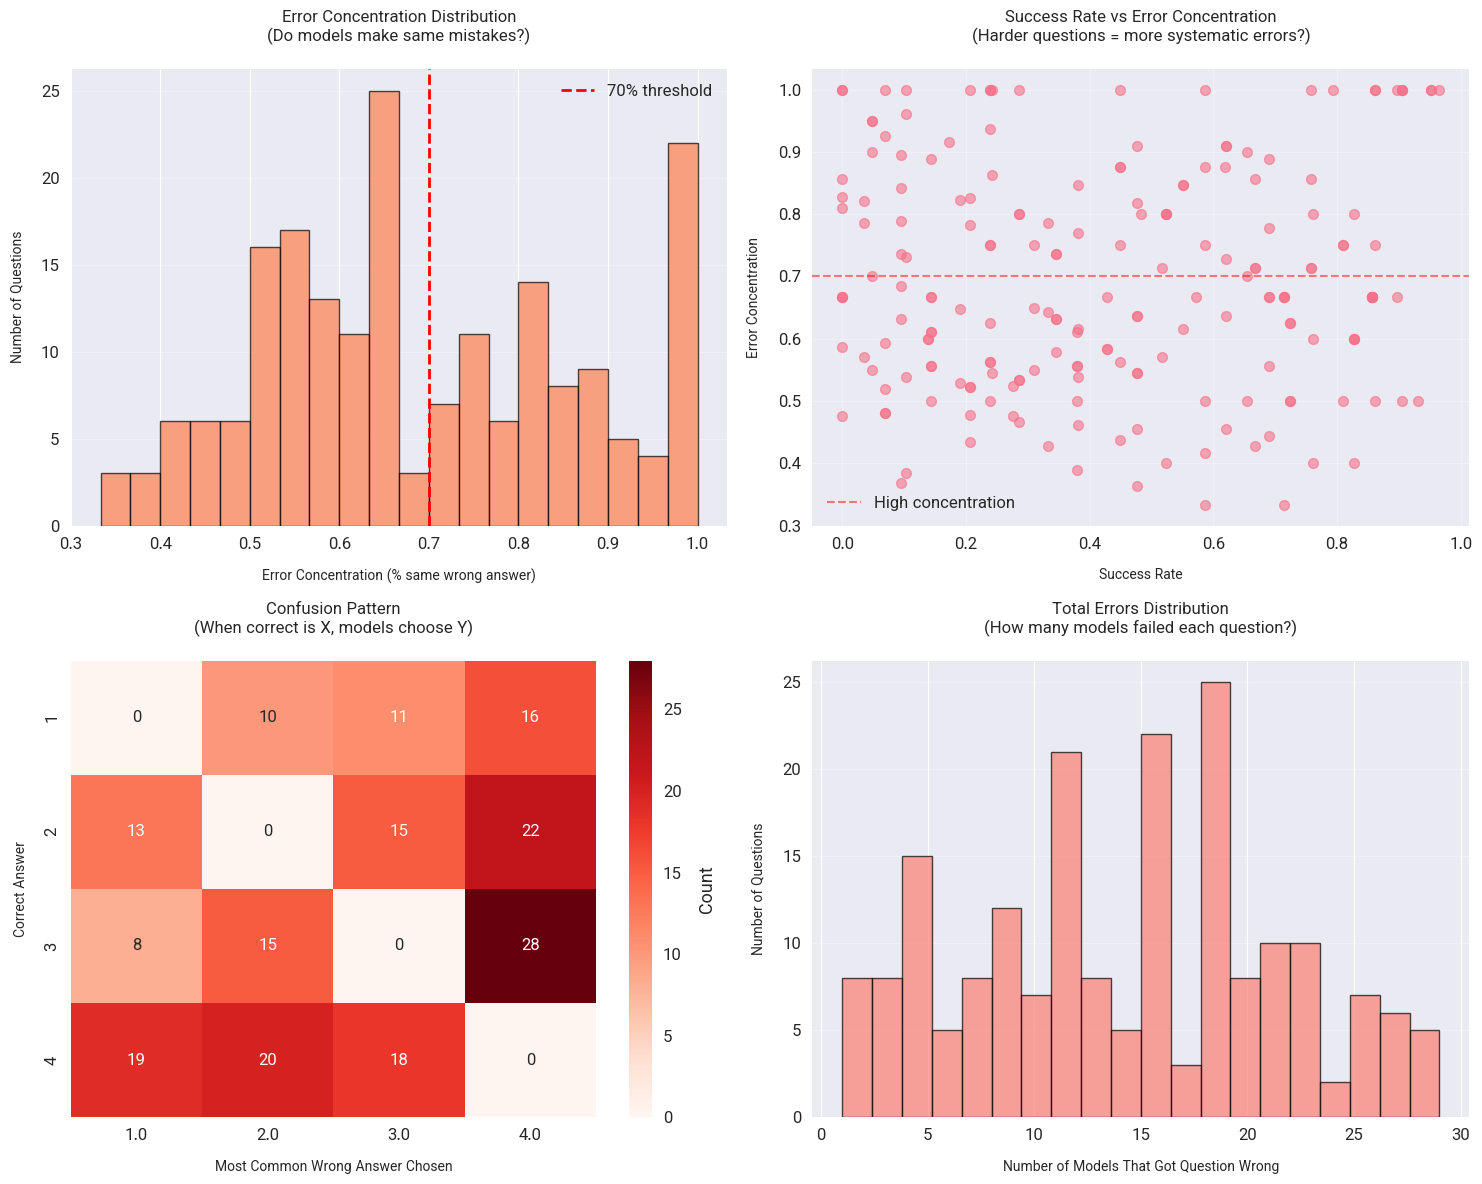


KEY INSIGHTS:
- 86 questions (44.1%) show systematic errors
- Average error concentration: 69.3%
- Models share similar misunderstandings of Persian poetry semantics


In [ ]:
# Visualize error patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Error concentration distribution
axes[0, 0].hist(error_df['error_concentration'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0.7, color='red', linestyle='--', linewidth=2, label='70% threshold')
axes[0, 0].set_xlabel('Error Concentration (% same wrong answer)', fontsize=10)
axes[0, 0].set_ylabel('Number of Questions', fontsize=10)
axes[0, 0].set_title('Error Concentration Distribution\n(Do models make same mistakes?)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Error concentration vs success rate
axes[0, 1].scatter(error_df['success_rate'], error_df['error_concentration'], alpha=0.6, s=50)
axes[0, 1].set_xlabel('Success Rate', fontsize=10)
axes[0, 1].set_ylabel('Error Concentration', fontsize=10)
axes[0, 1].set_title('Success Rate vs Error Concentration\n(Harder questions = more systematic errors?)', fontsize=12, fontweight='bold')
axes[0, 1].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='High concentration')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# 3. Confusion matrix
confusion_data = pd.crosstab(error_df['correct_answer'], error_df['most_common_wrong'], margins=False)
sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_xlabel('Most Common Wrong Answer Chosen', fontsize=10)
axes[1, 0].set_ylabel('Correct Answer', fontsize=10)
axes[1, 0].set_title('Confusion Pattern\n(When correct is X, models choose Y)', fontsize=12, fontweight='bold')

# 4. Distribution of total errors
axes[1, 1].hist(error_df['total_errors'], bins=20, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Models That Got Question Wrong', fontsize=10)
axes[1, 1].set_ylabel('Number of Questions', fontsize=10)
axes[1, 1].set_title('Total Errors Distribution\n(How many models failed each question?)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis-outputs/semantic_error_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKEY INSIGHTS:")
print(f"- {len(systematic_errors)} questions ({len(systematic_errors)/len(error_df)*100:.1f}%) show systematic errors")
print(f"- Average error concentration: {error_df['error_concentration'].mean():.1%}")
print(f"- Models share similar misunderstandings of Persian poetry semantics")


### 9.3 Metaphor and Poetic Device Analysis

Analyzing questions that involve metaphors, symbolism, and poetic devices common in Persian poetry:

In [26]:
# Analyze metaphor and symbolism understanding
# Common Persian poetry symbols and metaphors
persian_metaphors = {
    'عشق': 'Love', 'شراب': 'Wine (divine love)', 'می': 'Wine', 'باده': 'Wine',
    'گل': 'Flower (beauty)', 'بلبل': 'Nightingale (lover)', 'شمع': 'Candle',
    'پروانه': 'Moth (lover)', 'خار': 'Thorn', 'خون': 'Blood', 'دل': 'Heart',
    'جان': 'Soul', 'صبح': 'Morning', 'شب': 'Night', 'مجنون': 'Majnun',
    'لیلی': 'Layla', 'خدا': 'God', 'حق': 'Truth', 'مرگ': 'Death',
    'فنا': 'Annihilation', 'بقا': 'Eternity', 'سلطان': 'King',
    'فلک': 'Sky/Fate', 'دریا': 'Sea', 'کعبه': 'Kaaba', 'بت': 'Idol', 'زلف': 'Tresses'
}

# Analyze each question for metaphorical content
metaphor_analysis = []

for page in questions_data['pages']:
    for q in page['data']['questions']:
        q_id = q['id']

        # Check all text for metaphors
        all_text = q['stem'] + ' '
        for opt in q['options']:
            all_text += opt['mesra1'] + ' ' + opt['mesra2'] + ' '

        found_metaphors = [m for m in persian_metaphors if m in all_text]

        if q_id in question_stats.index:
            success_rate = question_stats.loc[q_id, 'success_rate']
        else:
            continue

        metaphor_analysis.append({
            'question_id': q_id,
            'metaphor_count': len(found_metaphors),
            'metaphors': ', '.join(found_metaphors) if found_metaphors else 'None',
            'success_rate': success_rate
        })

metaphor_df = pd.DataFrame(metaphor_analysis)

print("\nMETAPHOR AND SYMBOLISM ANALYSIS")
print("="*80)
print(f"Total questions analyzed: {len(metaphor_df)}")
print(f"Questions with metaphors: {len(metaphor_df[metaphor_df['metaphor_count'] > 0])} ({len(metaphor_df[metaphor_df['metaphor_count'] > 0])/len(metaphor_df)*100:.1f}%)")
print(f"Average metaphors per question: {metaphor_df['metaphor_count'].mean():.2f}")

# Compare success rates
with_metaphors = metaphor_df[metaphor_df['metaphor_count'] > 0]['success_rate'].mean()
without_metaphors = metaphor_df[metaphor_df['metaphor_count'] == 0]['success_rate'].mean()

print(f"\nAverage success rate:")
print(f"  WITH metaphors: {with_metaphors:.1%}")
print(f"  WITHOUT metaphors: {without_metaphors:.1%}")
print(f"  Difference: {abs(with_metaphors - without_metaphors):.1%}")

# Group by metaphor count
print("\nSuccess Rate by Number of Metaphors:")
for count in sorted(metaphor_df['metaphor_count'].unique()):
    subset = metaphor_df[metaphor_df['metaphor_count'] == count]
    print(f"  {count} metaphors: {subset['success_rate'].mean():.1%} (n={len(subset)})")

# Hardest metaphor-rich questions
print("\nHardest Metaphor-Rich Questions:")
hard_metaphors = metaphor_df[(metaphor_df['metaphor_count'] >= 2) & (metaphor_df['success_rate'] < 0.4)].sort_values('success_rate')
for idx, row in hard_metaphors.head(5).iterrows():
    print(f"  Q{row['question_id']}: {row['success_rate']:.1%} - Metaphors: {row['metaphors']}")



METAPHOR AND SYMBOLISM ANALYSIS
Total questions analyzed: 204
Questions with metaphors: 202 (99.0%)
Average metaphors per question: 3.00

Average success rate:
  WITH metaphors: 44.5%
  WITHOUT metaphors: 55.2%
  Difference: 10.7%

Success Rate by Number of Metaphors:
  0 metaphors: 55.2% (n=2)
  1 metaphors: 51.6% (n=32)
  2 metaphors: 41.4% (n=50)
  3 metaphors: 44.7% (n=52)
  4 metaphors: 39.3% (n=38)
  5 metaphors: 47.1% (n=17)
  6 metaphors: 44.8% (n=5)
  7 metaphors: 45.6% (n=6)
  8 metaphors: 72.2% (n=2)

Hardest Metaphor-Rich Questions:
  Q319: 0.0% - Metaphors: می, گل, بلبل
  Q472: 0.0% - Metaphors: عشق, می, شمع, دل, جان
  Q458: 0.0% - Metaphors: می, گل, خار, بت
  Q307: 0.0% - Metaphors: می, دل, خدا, دریا
  Q305: 0.0% - Metaphors: می, بت


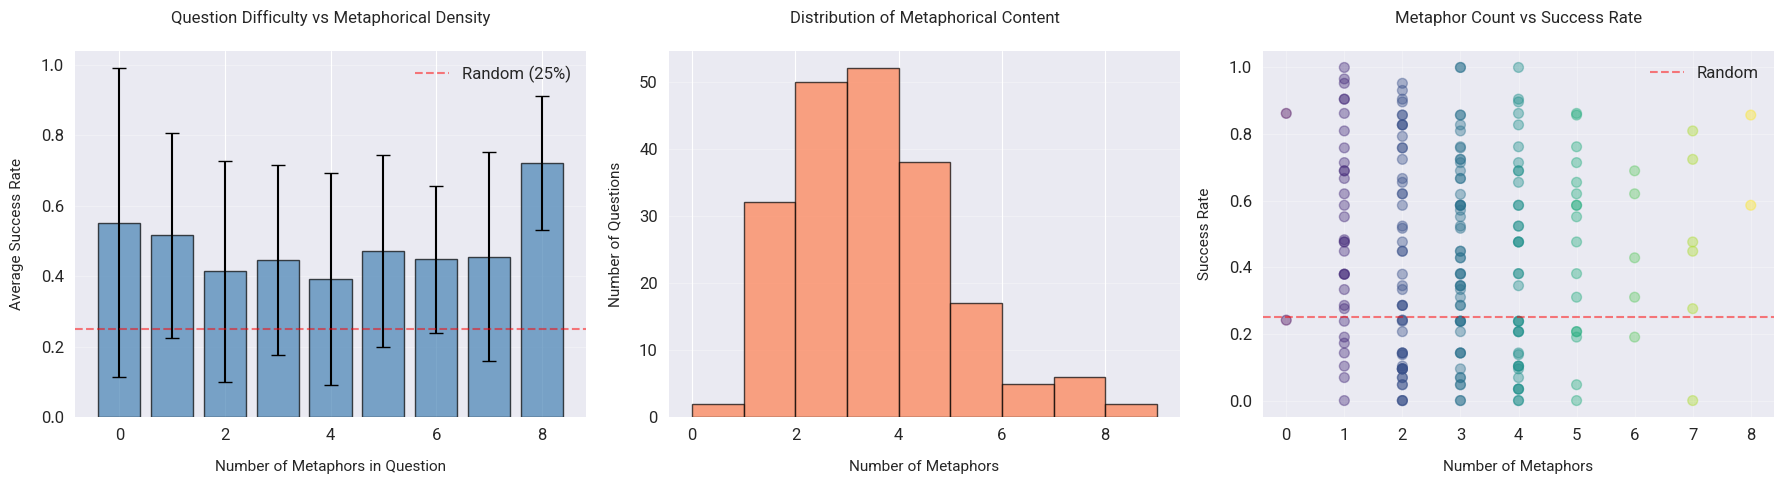

In [ ]:
# Visualize metaphor analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Success rate by metaphor count
metaphor_groups = metaphor_df.groupby('metaphor_count')['success_rate'].agg(['mean', 'std', 'count'])
axes[0].bar(metaphor_groups.index, metaphor_groups['mean'], yerr=metaphor_groups['std'],
            capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Metaphors in Question', fontsize=11)
axes[0].set_ylabel('Average Success Rate', fontsize=11)
axes[0].set_title('Question Difficulty vs Metaphorical Density', fontsize=12, fontweight='bold')
axes[0].axhline(0.25, color='red', linestyle='--', alpha=0.5, label='Random (25%)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# 2. Distribution of metaphor counts
axes[1].hist(metaphor_df['metaphor_count'], bins=range(0, metaphor_df['metaphor_count'].max()+2),
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Metaphors', fontsize=11)
axes[1].set_ylabel('Number of Questions', fontsize=11)
axes[1].set_title('Distribution of Metaphorical Content', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 3. Scatter: metaphor count vs success rate
axes[2].scatter(metaphor_df['metaphor_count'], metaphor_df['success_rate'],
                alpha=0.4, s=50, c=metaphor_df['metaphor_count'], cmap='viridis')
axes[2].set_xlabel('Number of Metaphors', fontsize=11)
axes[2].set_ylabel('Success Rate', fontsize=11)
axes[2].set_title('Metaphor Count vs Success Rate', fontsize=12, fontweight='bold')
axes[2].axhline(0.25, color='red', linestyle='--', alpha=0.5, label='Random')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('../analysis-outputs/metaphor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### 9.4 Reasoning Quality Analysis - Persian Understanding

Deep analysis of model reasoning to understand HOW models think about Persian poetry:

In [28]:
# Analyze reasoning quality with focus on Persian understanding
import json
from pathlib import Path
import re

reasoning_dir = Path('reasoning-outputs-improved')

# Keywords indicating Persian comprehension
persian_comprehension_markers = {
    'translation': ['translates', 'translation', 'means', 'meaning of'],
    'metaphor': ['metaphor', 'symbolic', 'symbolizes', 'represents'],
    'theme': ['theme', 'concept', 'idea', 'message'],
    'cultural': ['cultural', 'reference', 'story', 'Persian', 'Sufi'],
    'comparison': ['compare', 'comparing', 'contrast', 'similar', 'different'],
    'literary': ['poetic', 'literary', 'verse', 'couplet', 'imagery']
}

reasoning_analysis = []

print("\nANALYZING REASONING QUALITY FOR PERSIAN COMPREHENSION")
print("="*80)

reasoning_files = list(reasoning_dir.glob('*.json'))
print(f"Found {len(reasoning_files)} reasoning files\n")

for rf in reasoning_files[:500]:  # Sample for performance
    try:
        with open(rf, 'r', encoding='utf-8') as f:
            data = json.load(f)

        model_name = data.get('model_id', '').split('/')[-1]
        question_id = data.get('question_id')
        reasoning_text = data.get('reasoning_text', '')

        if not reasoning_text or not question_id:
            continue

        # Check for comprehension markers
        markers_found = {}
        for category, keywords in persian_comprehension_markers.items():
            count = sum(reasoning_text.lower().count(kw) for kw in keywords)
            markers_found[category] = count

        # Check if correct
        result = results_df[
            (results_df['question_id'] == question_id) &
            (results_df['model_name'].str.contains(model_name, na=False))
        ]

        is_correct = result['is_correct'].values[0] if len(result) > 0 else None

        word_count = len(reasoning_text.split())
        sentence_count = len(re.split(r'[.!?]+', reasoning_text))
        has_persian = bool(re.search(r'[\u0600-\u06FF]', reasoning_text))

        reasoning_analysis.append({
            'model': model_name,
            'question_id': question_id,
            'is_correct': is_correct,
            'word_count': word_count,
            'sentence_count': sentence_count,
            'has_persian_text': has_persian,
            **{f'{cat}_mentions': count for cat, count in markers_found.items()},
            'total_comprehension_markers': sum(markers_found.values())
        })

    except Exception:
        continue

reasoning_df = pd.DataFrame(reasoning_analysis)

if len(reasoning_df) > 0:
    print(f"Analyzed {len(reasoning_df)} reasoning samples\n")

    correct_reasoning = reasoning_df[reasoning_df['is_correct'] == True]
    incorrect_reasoning = reasoning_df[reasoning_df['is_correct'] == False]

    print("REASONING QUALITY: CORRECT VS INCORRECT ANSWERS")
    print("-" * 80)

    for metric in ['word_count', 'total_comprehension_markers', 'translation_mentions', 'metaphor_mentions']:
        if metric in reasoning_df.columns:
            correct_avg = correct_reasoning[metric].mean()
            incorrect_avg = incorrect_reasoning[metric].mean()
            print(f"\n{metric.replace('_', ' ').title()}:")
            print(f"  Correct:   {correct_avg:.2f}")
            print(f"  Incorrect: {incorrect_avg:.2f}")

    print(f"\nPersian Text in Reasoning:")
    print(f"  Correct: {correct_reasoning['has_persian_text'].mean()*100:.1f}%")
    print(f"  Incorrect: {incorrect_reasoning['has_persian_text'].mean()*100:.1f}%")
else:
    print("No reasoning data to analyze")



ANALYZING REASONING QUALITY FOR PERSIAN COMPREHENSION
Found 1781 reasoning files

Analyzed 441 reasoning samples

REASONING QUALITY: CORRECT VS INCORRECT ANSWERS
--------------------------------------------------------------------------------

Word Count:
  Correct:   715.13
  Incorrect: 979.19

Total Comprehension Markers:
  Correct:   21.89
  Incorrect: 28.83

Translation Mentions:
  Correct:   2.33
  Incorrect: 2.37

Metaphor Mentions:
  Correct:   1.15
  Incorrect: 1.69

Persian Text in Reasoning:
  Correct: 83.2%
  Incorrect: 92.3%


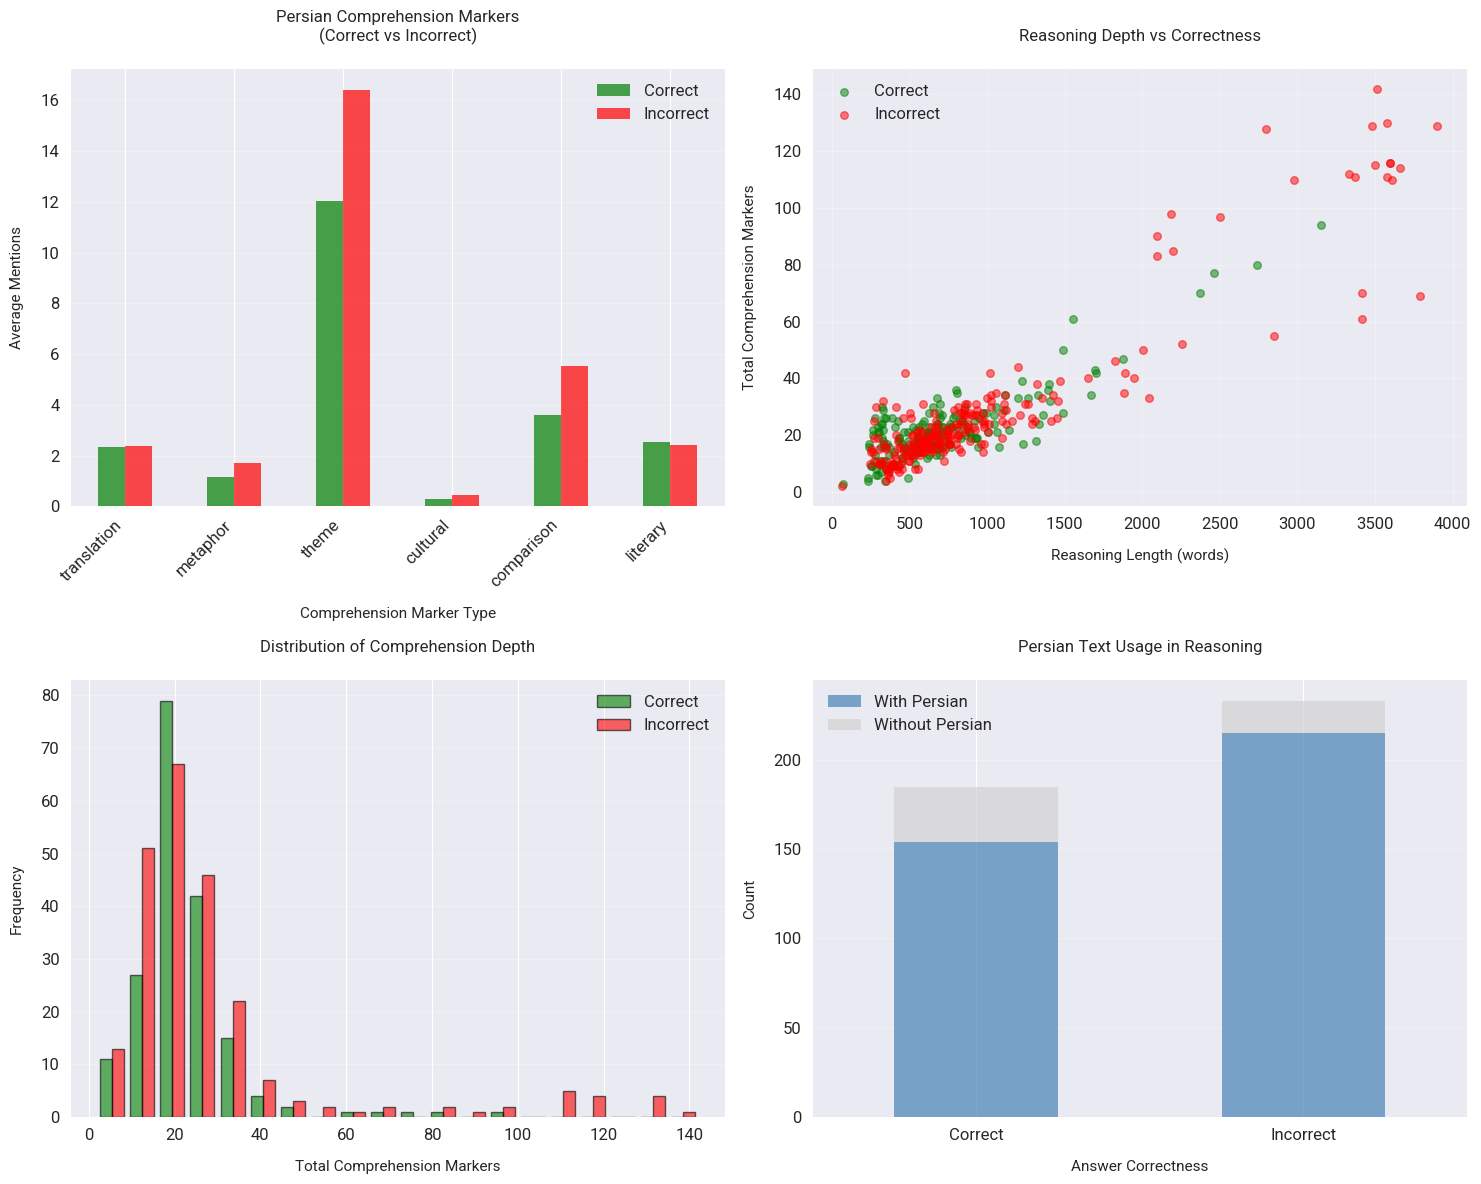

In [ ]:
# Visualize reasoning quality
if len(reasoning_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Comprehension markers comparison
    marker_comparison = pd.DataFrame({
        'Correct': [correct_reasoning[f'{cat}_mentions'].mean() for cat in persian_comprehension_markers.keys()],
        'Incorrect': [incorrect_reasoning[f'{cat}_mentions'].mean() for cat in persian_comprehension_markers.keys()]
    }, index=list(persian_comprehension_markers.keys()))

    marker_comparison.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'], alpha=0.7)
    axes[0, 0].set_xlabel('Comprehension Marker Type', fontsize=11)
    axes[0, 0].set_ylabel('Average Mentions', fontsize=11)
    axes[0, 0].set_title('Persian Comprehension Markers\n(Correct vs Incorrect)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # 2. Reasoning length vs correctness
    axes[0, 1].scatter(correct_reasoning['word_count'], correct_reasoning['total_comprehension_markers'],
                       alpha=0.5, s=30, c='green', label='Correct')
    axes[0, 1].scatter(incorrect_reasoning['word_count'], incorrect_reasoning['total_comprehension_markers'],
                       alpha=0.5, s=30, c='red', label='Incorrect')
    axes[0, 1].set_xlabel('Reasoning Length (words)', fontsize=11)
    axes[0, 1].set_ylabel('Total Comprehension Markers', fontsize=11)
    axes[0, 1].set_title('Reasoning Depth vs Correctness', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Distribution of markers
    axes[1, 0].hist([correct_reasoning['total_comprehension_markers'],
                     incorrect_reasoning['total_comprehension_markers']],
                    bins=20, label=['Correct', 'Incorrect'],
                    color=['green', 'red'], alpha=0.6, edgecolor='black')
    axes[1, 0].set_xlabel('Total Comprehension Markers', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Comprehension Depth', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Persian text usage
    persian_usage = pd.DataFrame({
        'With Persian': [correct_reasoning['has_persian_text'].sum(), incorrect_reasoning['has_persian_text'].sum()],
        'Without Persian': [(~correct_reasoning['has_persian_text']).sum(), (~incorrect_reasoning['has_persian_text']).sum()]
    }, index=['Correct', 'Incorrect'])

    persian_usage.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['steelblue', 'lightgray'], alpha=0.7)
    axes[1, 1].set_xlabel('Answer Correctness', fontsize=11)
    axes[1, 1].set_ylabel('Count', fontsize=11)
    axes[1, 1].set_title('Persian Text Usage in Reasoning', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig('../analysis-outputs/reasoning_quality_persian.png', dpi=300, bbox_inches='tight')
    plt.show()


### 9.5 Case Studies - Persian Poetry Understanding

Detailed examination of specific questions showing actual Persian text + model reasoning:

In [30]:
# Deep dive into specific cases with Persian text and reasoning
print("\n" + "="*80)
print("CASE STUDIES: HOW MODELS UNDERSTAND PERSIAN POETRY")
print("="*80 + "\n")

case_studies = []

# Case 1: Hardest question
if len(question_stats) > 0:
    hardest_q = question_stats.nsmallest(1, 'success_rate').index[0]
    case_studies.append(('HARDEST QUESTION', hardest_q))

# Case 2: Systematic error
if 'systematic_errors' in dir() and len(systematic_errors) > 0:
    systematic_q = systematic_errors.iloc[0]['question_id']
    case_studies.append(('SYSTEMATIC ERROR', int(systematic_q)))

# Case 3: Metaphor-rich
if 'metaphor_df' in dir() and len(metaphor_df[metaphor_df['metaphor_count'] >= 3]) > 0:
    metaphor_rich_q = metaphor_df[metaphor_df['metaphor_count'] >= 3].nsmallest(1, 'success_rate').iloc[0]['question_id']
    case_studies.append(('METAPHOR-RICH', int(metaphor_rich_q)))

for case_name, q_id in case_studies:
    print("\n" + "="*80)
    print(f"CASE: {case_name}")
    print("="*80 + "\n")

    # Find question
    question_data = None
    for page in questions_data['pages']:
        for q in page['data']['questions']:
            if q['id'] == q_id:
                question_data = q
                break
        if question_data:
            break

    if not question_data:
        continue

    correct_ans = answer_keys.get(str(q_id))
    success_rate = question_stats.loc[q_id, 'success_rate'] if q_id in question_stats.index else 0

    print(f"Question ID: {q_id} | Success: {success_rate:.1%} | Correct: Option {correct_ans}\n")
    print(f"سؤال: {question_data['stem']}")
    print("\n" + "-"*80 + "\n")

    for opt in question_data['options']:
        marker = "✓ CORRECT" if opt['label'] == correct_ans else ""
        print(f"گزینه {opt['label']}: {marker}")
        print(f"  {opt['mesra1']}")
        print(f"  {opt['mesra2']}")
        print()

    print("-"*80)
    print("SAMPLE MODEL REASONING:\n")

    reasoning_files = list(reasoning_dir.glob(f'*_q{q_id}.json'))

    if reasoning_files:
        shown = 0
        for rf in reasoning_files[:5]:
            try:
                with open(rf, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                model_name = data.get('model_id', 'Unknown')
                reasoning_text = data.get('reasoning_text', '')

                result = results_df[
                    (results_df['question_id'] == q_id) &
                    (results_df['model_name'].str.contains(model_name.split('/')[-1], na=False))
                ]

                if len(result) > 0:
                    is_correct = result['is_correct'].values[0]
                    model_answer = result['model_answer'].values[0]

                    status = "✓ CORRECT" if is_correct else "✗ INCORRECT"
                    print(f"\nModel: {model_name}")
                    print(f"Answer: Option {model_answer} {status}")
                    print(f"\nReasoning (excerpt):")
                    print(reasoning_text[:700] + "..." if len(reasoning_text) > 700 else reasoning_text)
                    print("\n" + "-"*80)

                    shown += 1
                    if shown >= 2:
                        break

            except Exception:
                continue
    else:
        print("No reasoning available\n")

    print("\n")

print("="*80)
print("END OF CASE STUDIES")
print("="*80)



CASE STUDIES: HOW MODELS UNDERSTAND PERSIAN POETRY


CASE: HARDEST QUESTION

Question ID: 458 | Success: 0.0% | Correct: Option 3

سؤال: مفهوم بیت من آزاده از خاک آزادگانم گُلِ صبر می پرورد دامن من از کدام گزینه دورتر است؟

--------------------------------------------------------------------------------

گزینه 1: 
  ز دانش روان ها پر از رامش است
  برِ ما شکیبایی و دانش است

گزینه 2: 
  وی همه آزادگی ز طبع تو پیدا
  ای همه ناراستی ز کلک (قلم) تو پنهان

گزینه 3: ✓ CORRECT
  همه دانند که در صحبت گل خاری هست
  صبر بر جور رقیبت چه کنم گر نکنم

گزینه 4: 
  شکیبایی و دوری پیشه می کرد
  ز خلق آن ماه چون اندیشه می کرد

--------------------------------------------------------------------------------
SAMPLE MODEL REASONING:


Model: openai/gpt-oss-20b
Answer: Option 2.0 ✗ INCORRECT

Reasoning (excerpt):
We need to analyze each option. They are Persian lines, maybe couplets. We need to find which one deviates conceptually from others.

Let's translate or interpret each.

Option 1: "ز دانش روان ها

## 10. Comprehensive Performance Report


In [31]:
# Generate comprehensive summary report
print("\n" + "="*100)
print(" "*30 + "COMPREHENSIVE PERFORMANCE REPORT")
print("="*100)

print("\n📊 DATASET OVERVIEW")
print(f"  Total questions: {len(question_stats)}")
print(f"  Total models tested: {len(model_performance)}")
print(f"  Total responses: {len(results_df)}")

print("\n🏆 TOP PERFORMERS")
for i, (model, row) in enumerate(model_performance.head(5).iterrows(), 1):
    print(f"  {i}. {model}")
    print(f"     Accuracy: {row['accuracy_pct']:.2f}% ± {(row['ci_upper']-row['ci_lower'])/2:.2f}%")
    print(f"     Efficiency: {row['efficiency']:.2f} correct/1k tokens")

print("\n📈 AGGREGATE STATISTICS")
print(f"  Mean model accuracy: {model_performance['accuracy_pct'].mean():.2f}%")
print(f"  Median model accuracy: {model_performance['accuracy_pct'].median():.2f}%")
print(f"  Best model: {model_performance['accuracy_pct'].max():.2f}%")
print(f"  Worst model: {model_performance['accuracy_pct'].min():.2f}%")
print(f"  Models above random (25%): {(model_performance['accuracy_pct'] > 25).sum()} / {len(model_performance)}")

print("\n🎯 QUESTION DIFFICULTY")
print(f"  Mean question success rate: {question_stats['success_rate_pct'].mean():.2f}%")
print(f"  Hardest question: ID {question_stats.index[0]} ({question_stats['success_rate_pct'].min():.2f}% success)")
print(f"  Easiest question: ID {question_stats.index[-1]} ({question_stats['success_rate_pct'].max():.2f}% success)")
print(f"  Questions with >50% success: {(question_stats['success_rate_pct'] > 50).sum()} ({(question_stats['success_rate_pct'] > 50).sum() / len(question_stats) * 100:.1f}%)")

print("\n🤝 INTER-MODEL AGREEMENT")
upper_triangle = agreement_matrix[np.triu_indices_from(agreement_matrix, k=1)]
print(f"  Mean pairwise agreement: {upper_triangle.mean():.2f}%")
print(f"  Median pairwise agreement: {np.median(upper_triangle):.2f}%")
print(f"  Mean consensus rate: {consensus_stats['consensus_rate'].mean():.2f}%")

print("\n💰 EFFICIENCY INSIGHTS")
best_efficient = model_performance.nlargest(1, 'efficiency').iloc[0]
print(f"  Most efficient model: {model_performance.nlargest(1, 'efficiency').index[0]}")
print(f"    {best_efficient['efficiency']:.2f} correct/1k tokens at {best_efficient['accuracy_pct']:.1f}% accuracy")

print("\n🎭 THEMATIC ANALYSIS")
print(f"  Themes identified: {len(theme_difficulty)}")
if len(theme_difficulty) > 0:
    hardest_theme = theme_difficulty.index[0]
    easiest_theme = theme_difficulty.index[-1]
    print(f"  Hardest theme: {hardest_theme} ({theme_difficulty.loc[hardest_theme, 'avg_difficulty']:.1f} difficulty)")
    print(f"  Easiest theme: {easiest_theme} ({theme_difficulty.loc[easiest_theme, 'avg_difficulty']:.1f} difficulty)")

print("\n" + "="*100)
print(" "*35 + "END OF REPORT")
print("="*100)


                              COMPREHENSIVE PERFORMANCE REPORT

📊 DATASET OVERVIEW
  Total questions: 199
  Total models tested: 29
  Total responses: 5000

🏆 TOP PERFORMERS
  1. google/gemini-2.5-pro
     Accuracy: 70.00% ± 9.03%
     Efficiency: 0.39 correct/1k tokens
  2. moonshotai/kimi-k2-thinking
     Accuracy: 62.00% ± 9.56%
     Efficiency: 0.25 correct/1k tokens
  3. google/gemini-2.5-flash
     Accuracy: 61.00% ± 6.78%
     Efficiency: 0.91 correct/1k tokens
  4. qwen/qwen3-max
     Accuracy: 59.00% ± 9.69%
     Efficiency: 0.59 correct/1k tokens
  5. openai/gpt-5-mini
     Accuracy: 57.00% ± 9.75%
     Efficiency: 0.49 correct/1k tokens

📈 AGGREGATE STATISTICS
  Mean model accuracy: 46.47%
  Median model accuracy: 47.00%
  Best model: 70.00%
  Worst model: 30.00%
  Models above random (25%): 29 / 29

🎯 QUESTION DIFFICULTY
  Mean question success rate: 44.23%
  Hardest question: ID 458 (0.00% success)
  Easiest question: ID 237 (100.00% success)
  Questions with >50% success

## 11. Export Analysis Results


In [ ]:
# Export comprehensive analysis results
output_dir = Path('../analysis-outputs')
output_dir.mkdir(exist_ok=True)

# Save model performance
model_performance.to_csv(output_dir / 'model_performance_detailed.csv')
print(f"✅ Saved: {output_dir / 'model_performance_detailed.csv'}")

# Save question difficulty
question_stats.to_csv(output_dir / 'question_difficulty_analysis.csv')
print(f"✅ Saved: {output_dir / 'question_difficulty_analysis.csv'}")

# Save agreement matrix
agreement_df.to_csv(output_dir / 'model_agreement_matrix.csv')
print(f"✅ Saved: {output_dir / 'model_agreement_matrix.csv'}")

# Save theme analysis
theme_difficulty.to_csv(output_dir / 'theme_difficulty_analysis.csv')
print(f"✅ Saved: {output_dir / 'theme_difficulty_analysis.csv'}")

# Save statistical significance results
sig_df.to_csv(output_dir / 'statistical_significance.csv', index=False)
print(f"✅ Saved: {output_dir / 'statistical_significance.csv'}")

print("\n✅ All analysis results exported successfully!")

✅ Saved: analysis-outputs/model_performance_detailed.csv
✅ Saved: analysis-outputs/question_difficulty_analysis.csv
✅ Saved: analysis-outputs/model_agreement_matrix.csv
✅ Saved: analysis-outputs/theme_difficulty_analysis.csv
✅ Saved: analysis-outputs/statistical_significance.csv

✅ All analysis results exported successfully!
